In [1]:
#Terceros
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
#Este proyecto
import set_paths
from config.paths import RAW_DATA, CLEAN_DATA, GROUPED_DATA, SCORED_DATA
from config.config import paleta
from src.pipeline import full_treatment, get_top
from src.utils import extraer_sufijo_csv
from src.visuals import bar_plot, hist_plot

## PAVC-SCORE (Price, Age, Variation Coeficient)
$$

score = w_1\tilde{p} + w_2(1 - \bar{a}) + w_3(1-c_v)

$$

## QS-SCORE (QUALITY, STRENGHT)

$$
score = w_qQ +w_sS
$$

Donde

$$
Q = w_1\tilde{p} + w_2(1 - \bar{a})
$$

$$
S = \ln(1+n)
$$

### Notación:

- $\tilde{p}$ --> $Precio/m^2$ (mediana)
- $\bar{a}$ --> Edad de anuncios promedio
- $c_v$ --> Coeficiente de variación del precio ($\frac{\bar{p}}{\sigma_p}$)
- $n$ --> Cantidad de anuncios por colonia
### Aclaraciones:
- Todas las variables están reescaladas entre 0 y 1, asígnandole 1 a la colonia con el valor más alto de cada estado.
- Los pesos se escogen para que sumen 1, así $0 \leq score \leq 1$
- Todos los pesos son editables y se encuentran en ../config/config.py

## TOP'S Y DISTRIBUCIONES DE PRECIOS POR ESTADO

In [2]:
mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 8.5,
})

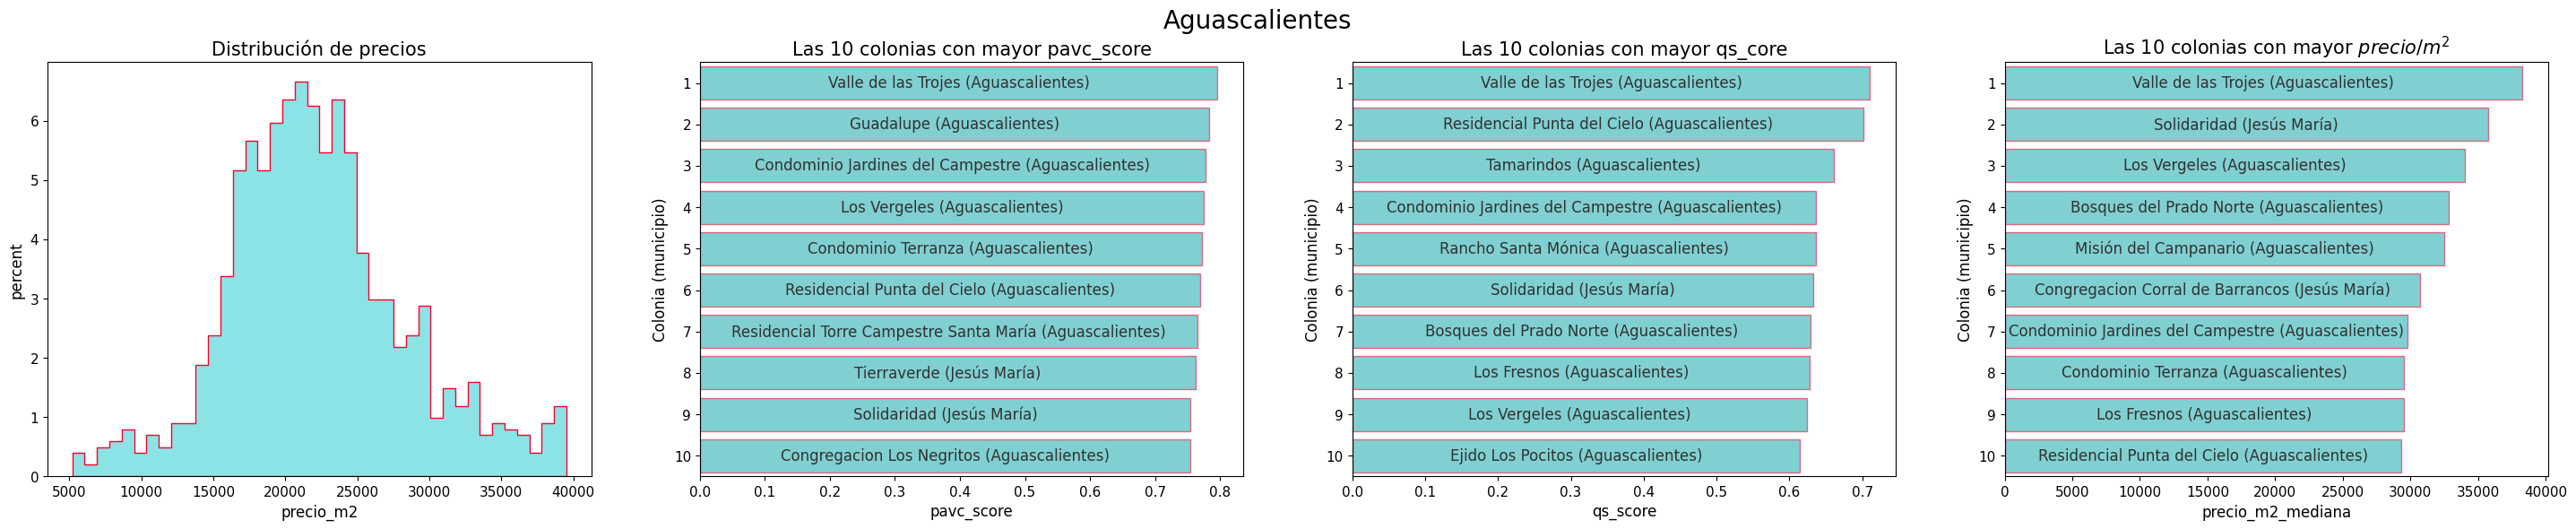

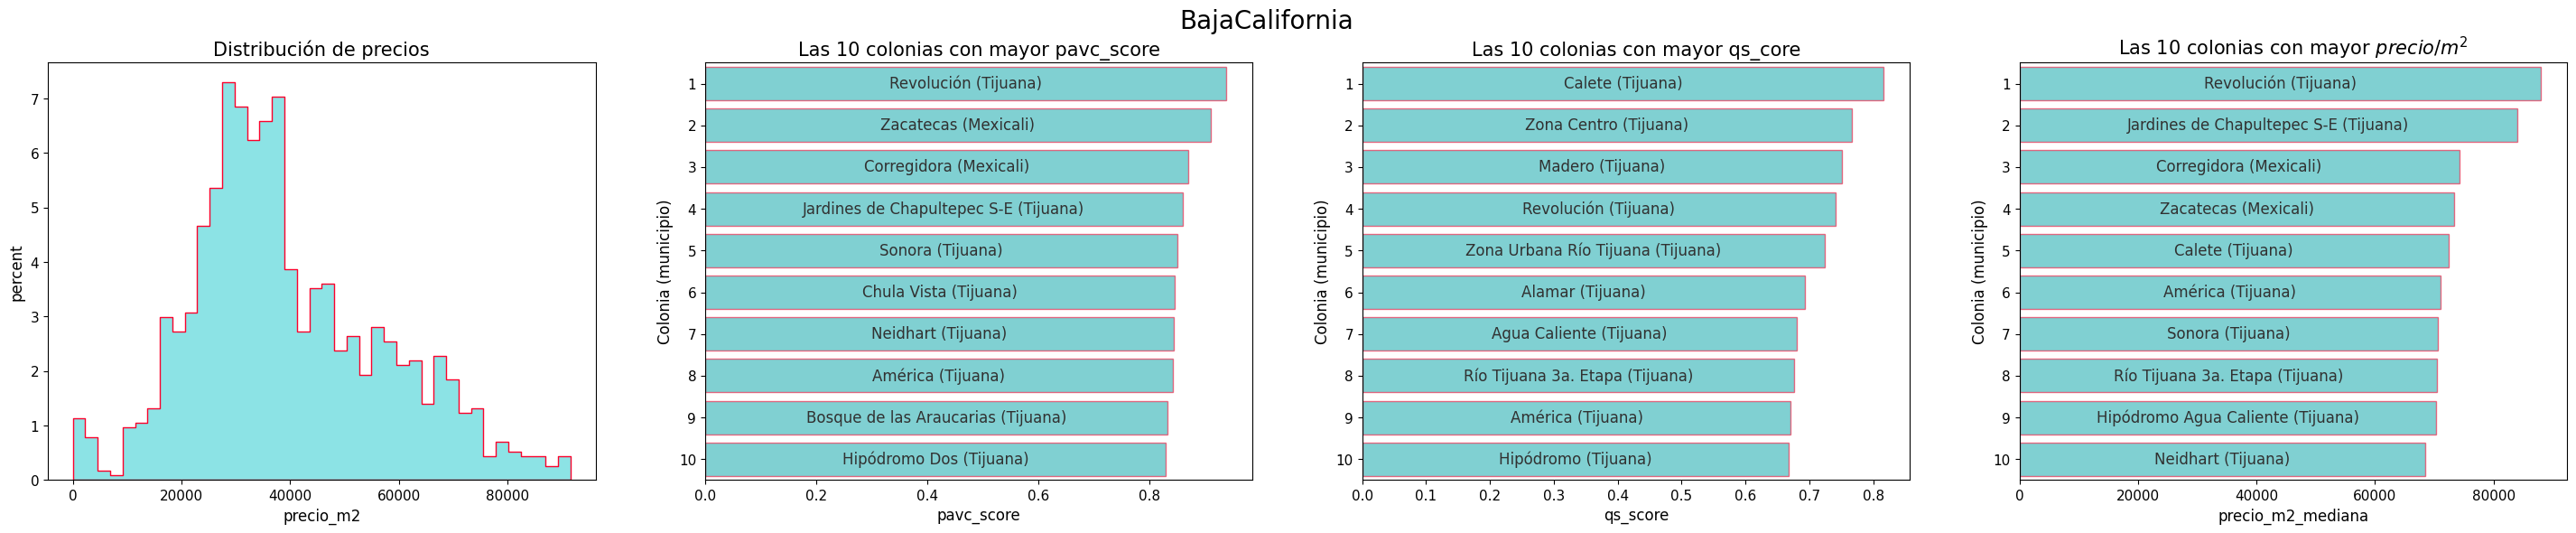

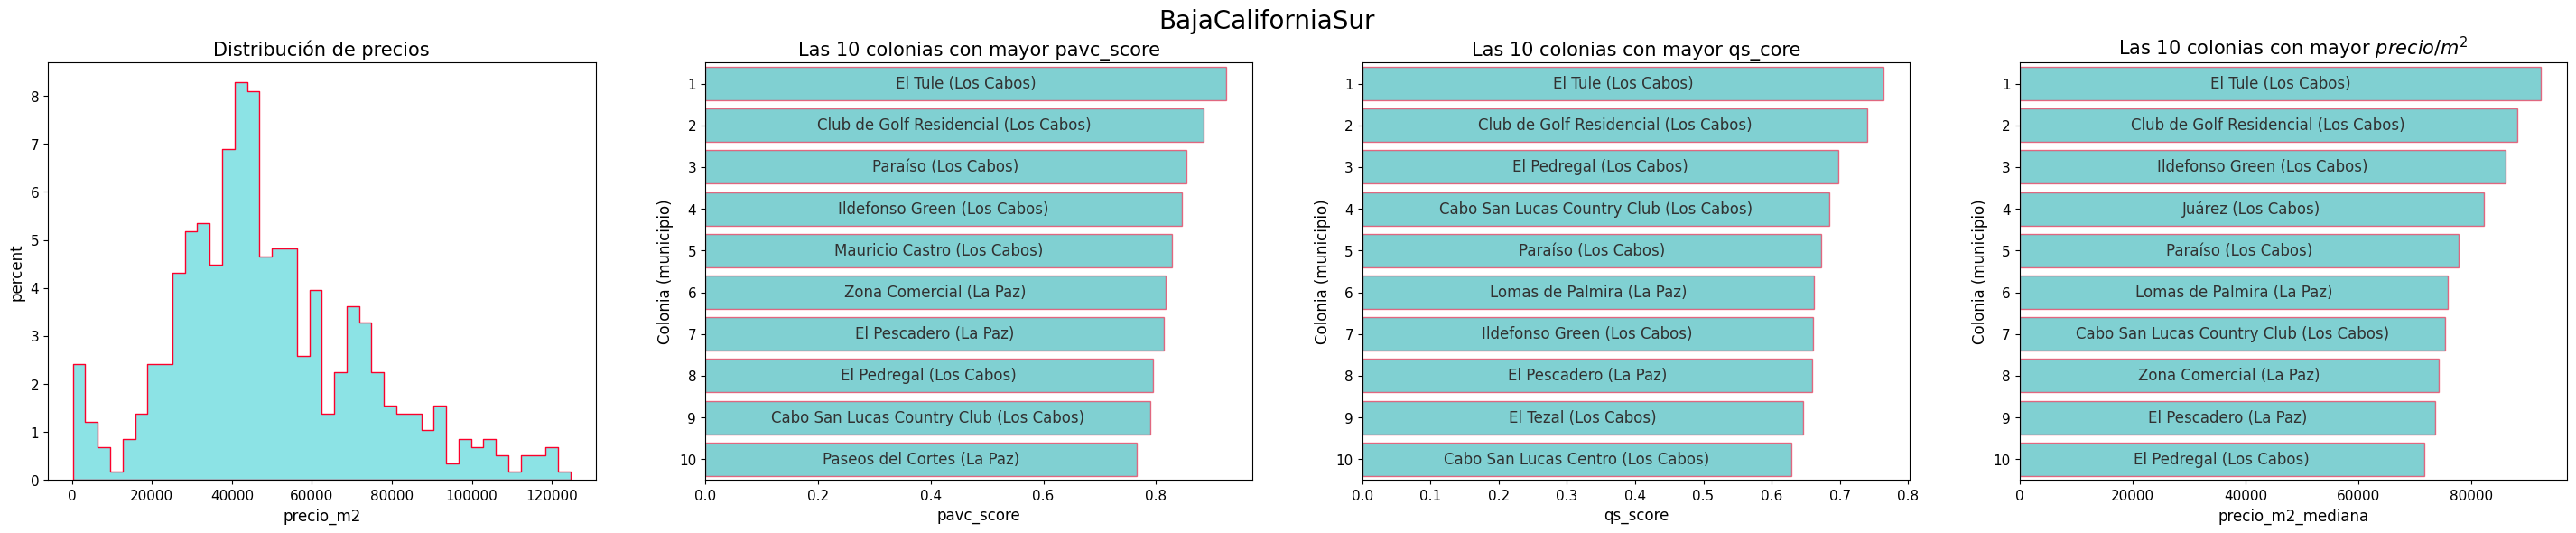

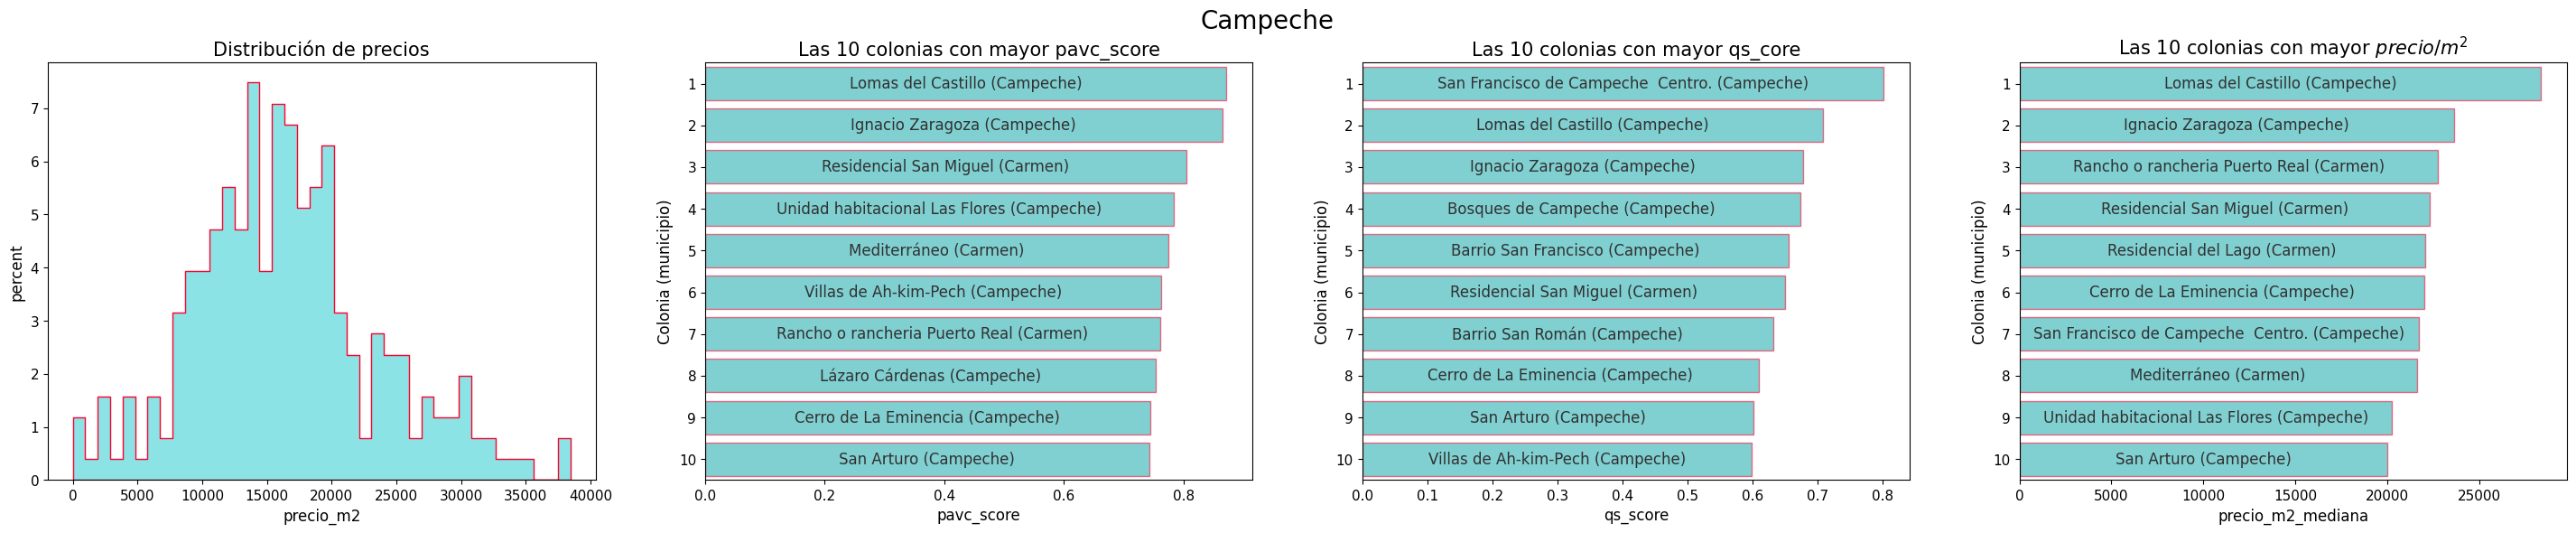

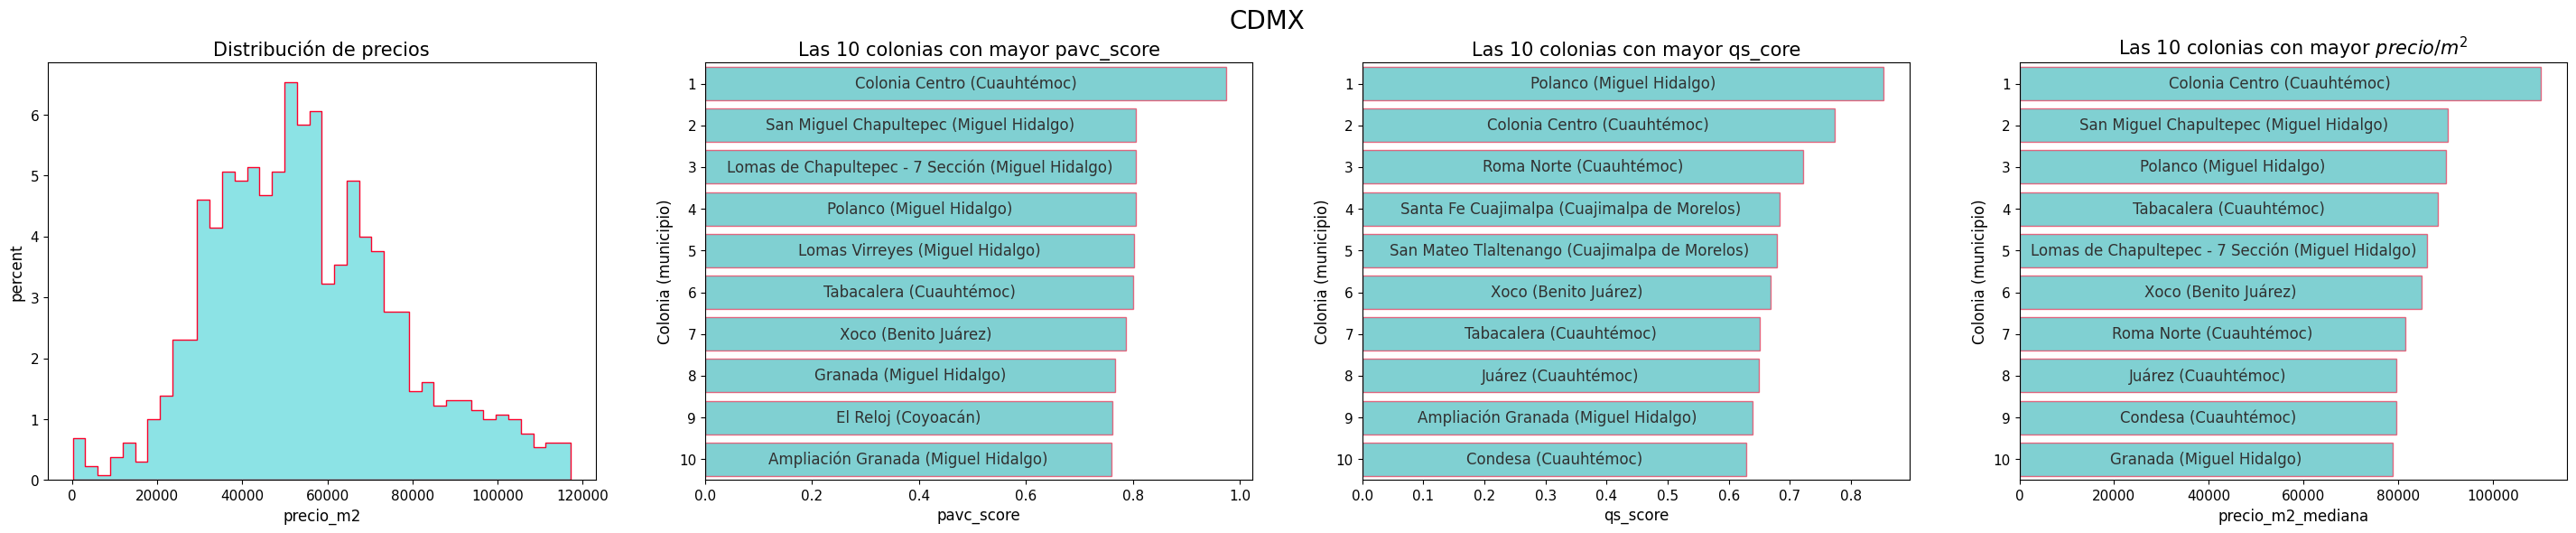

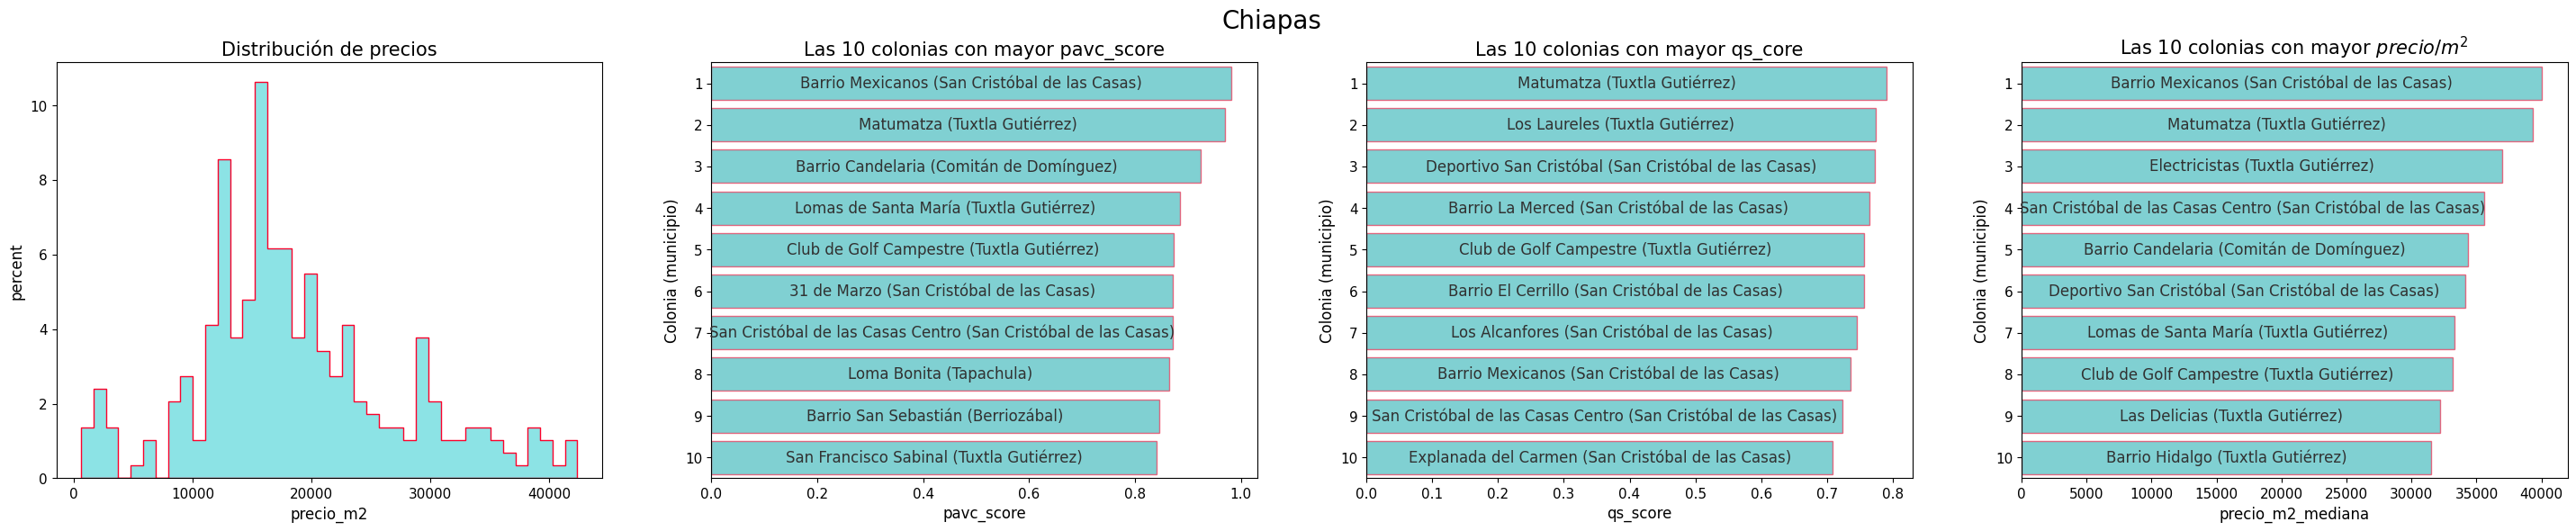

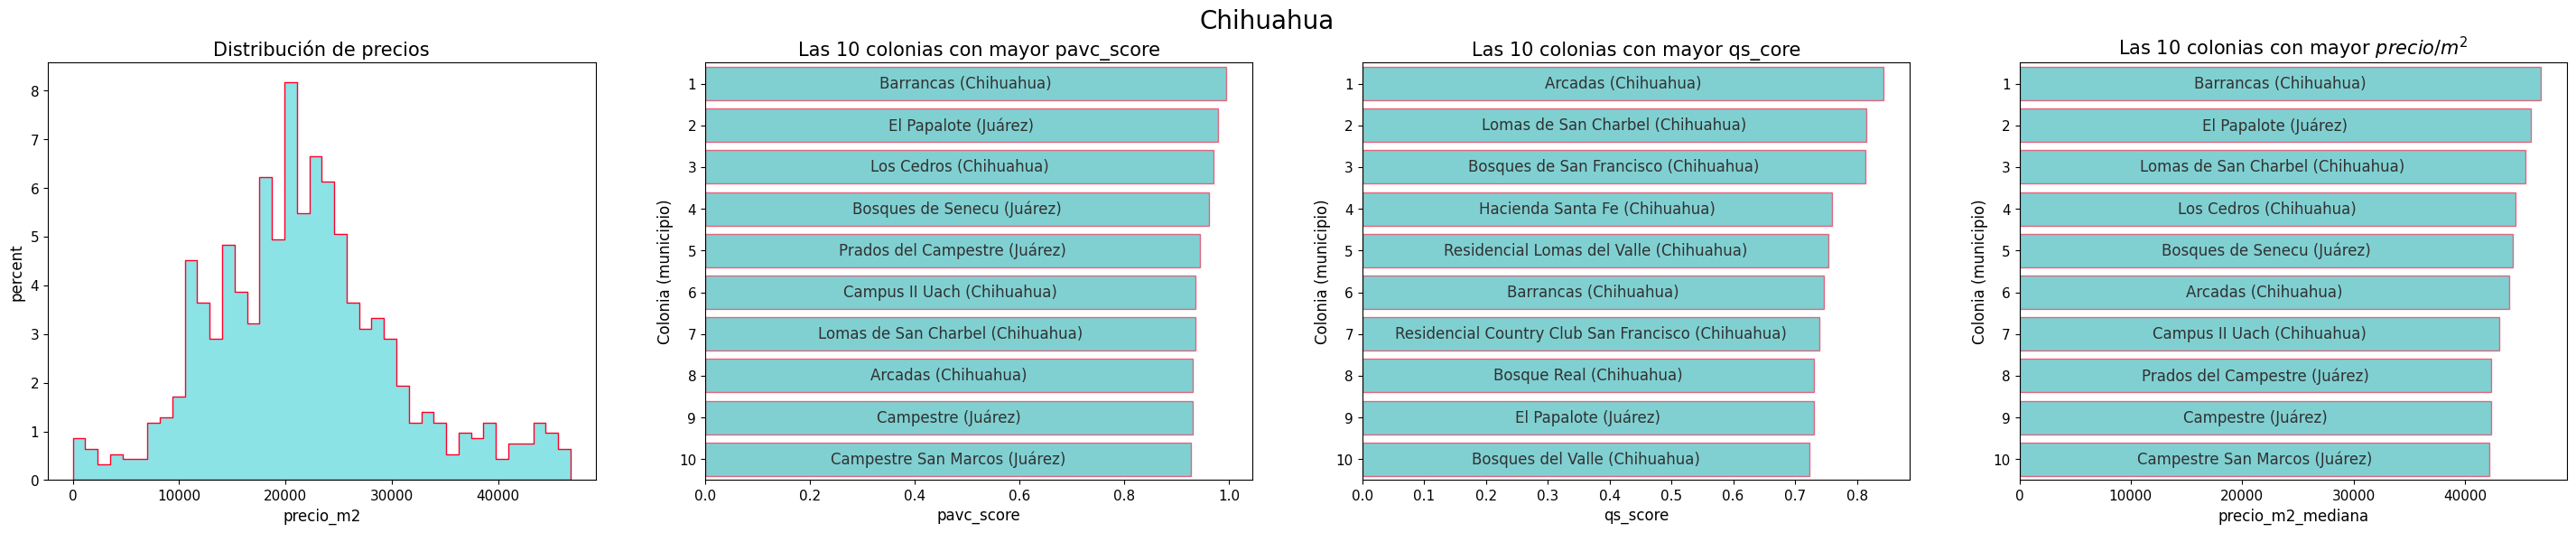

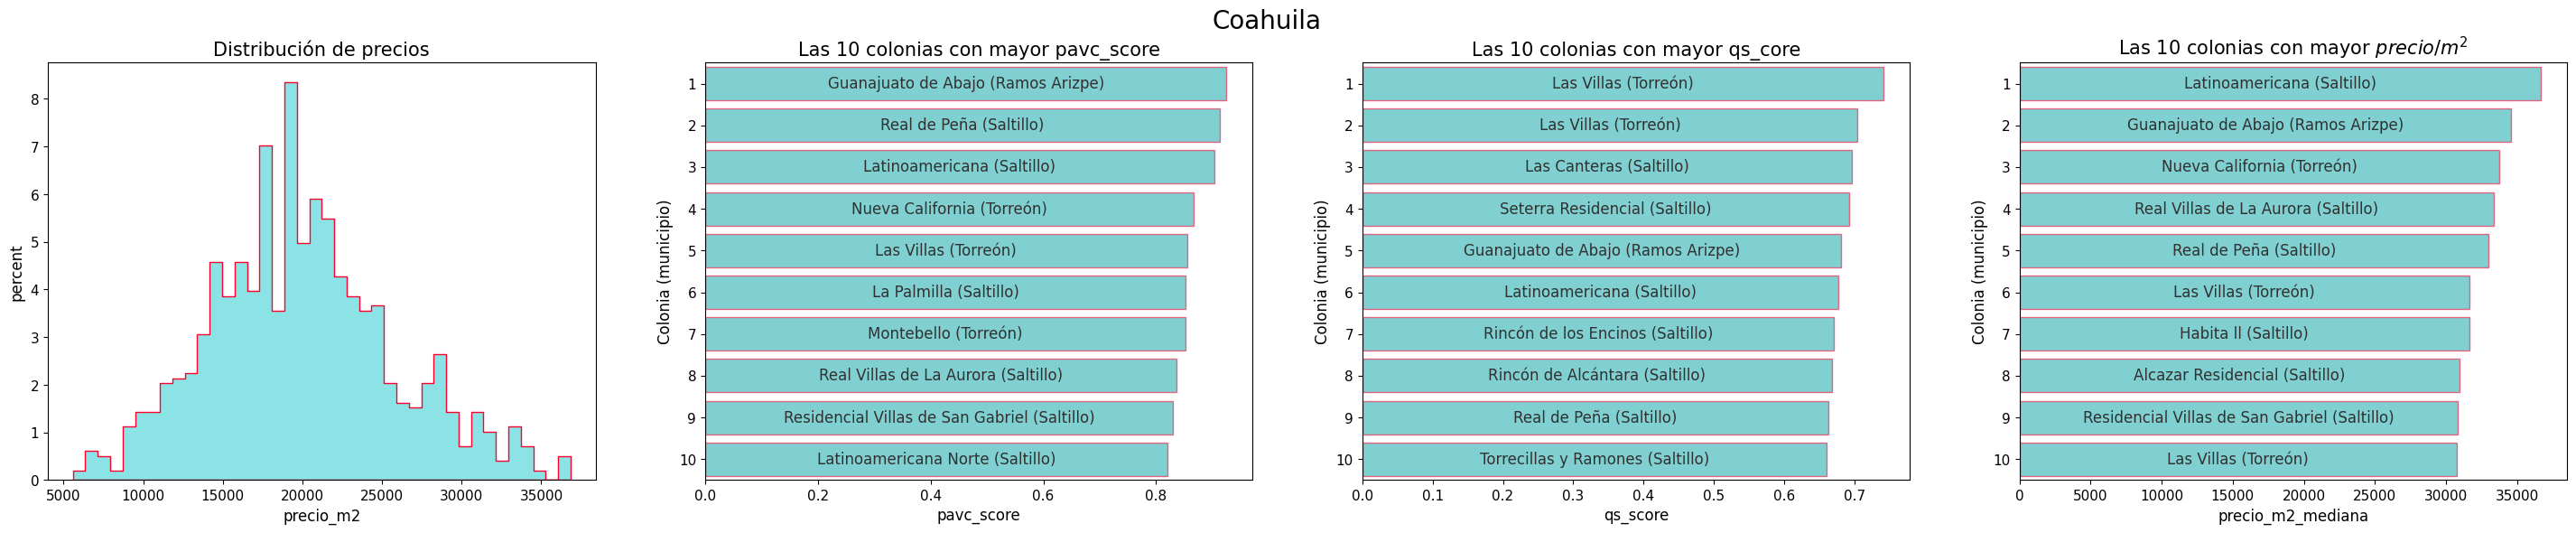

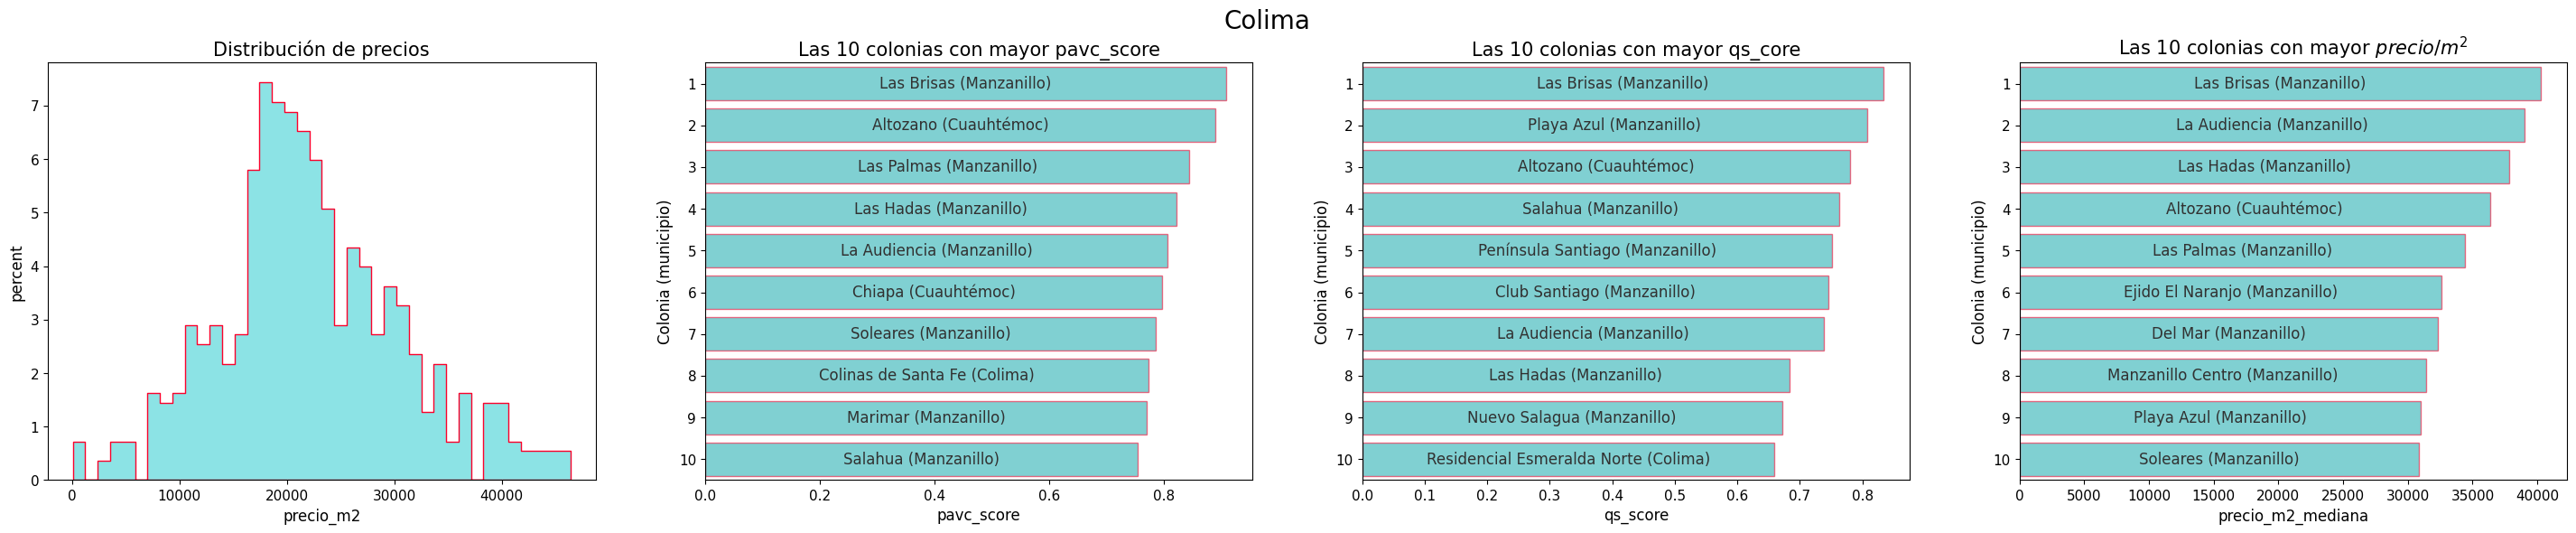

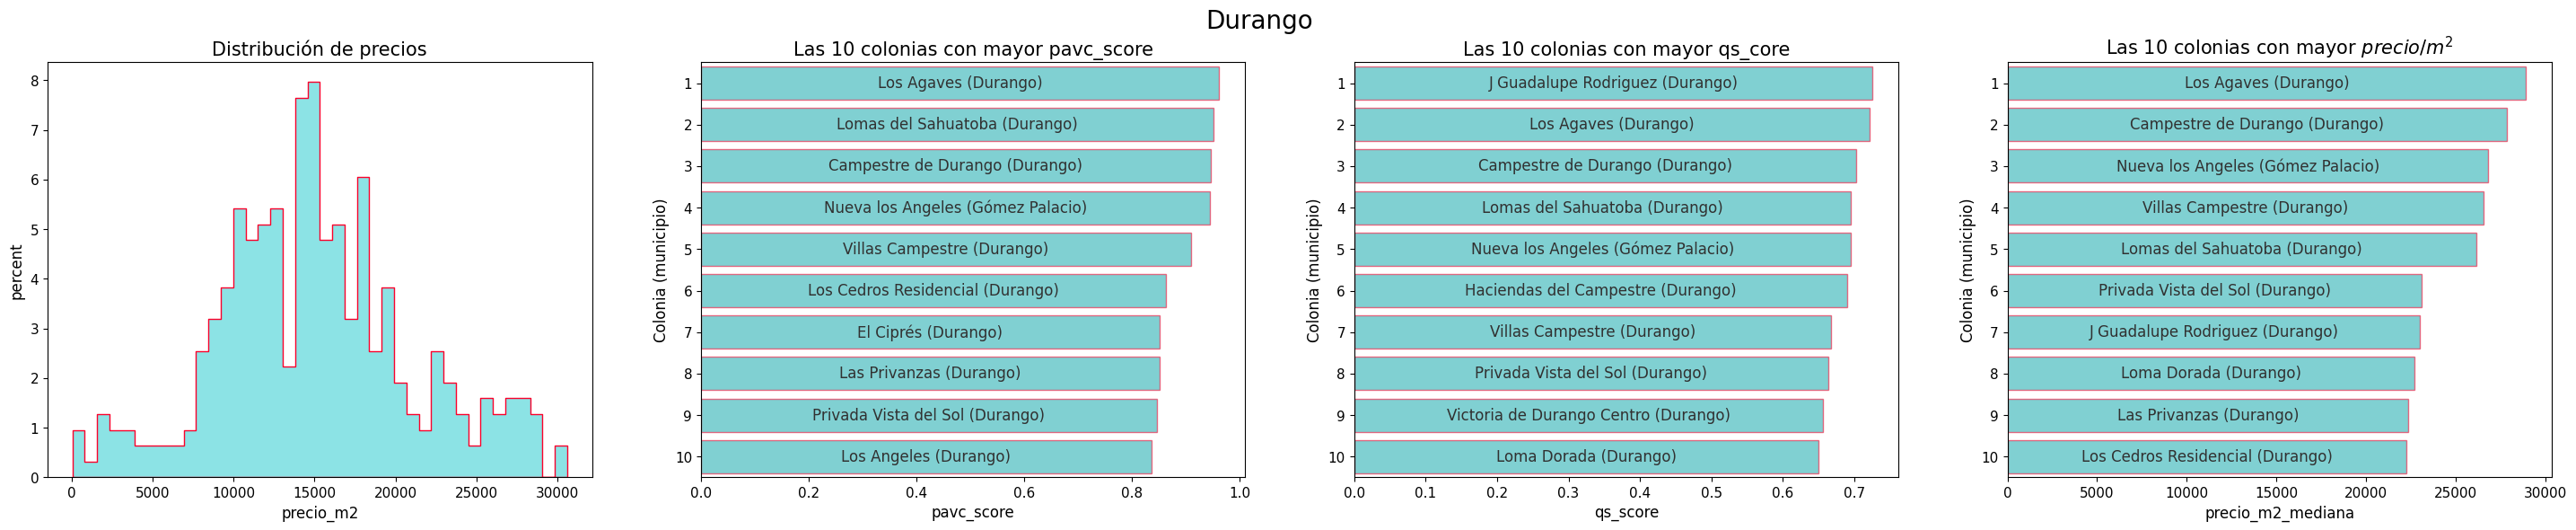

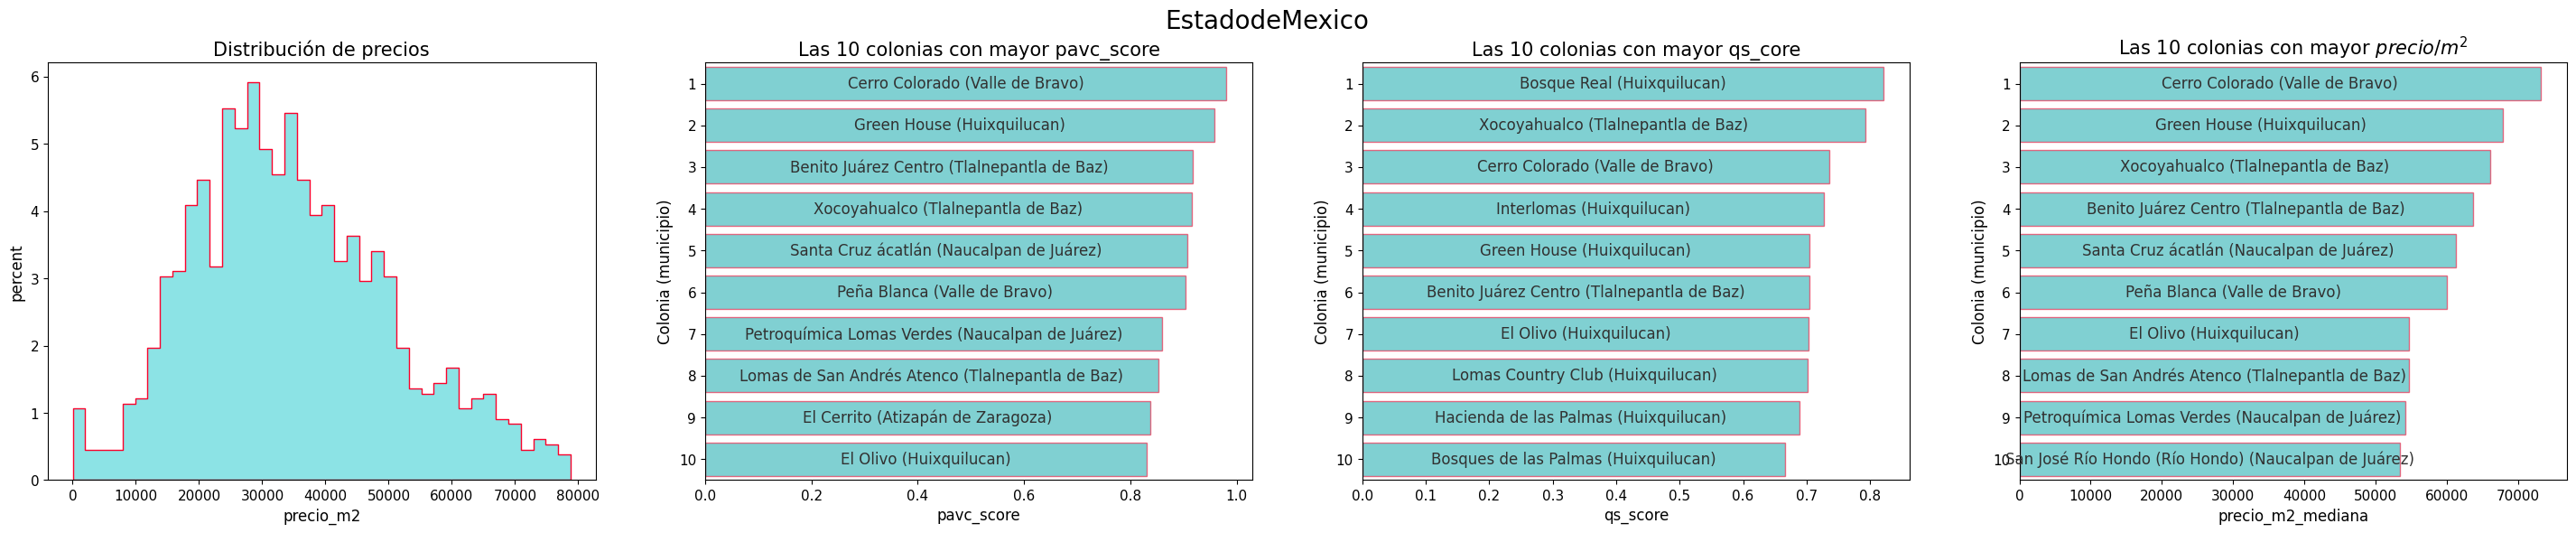

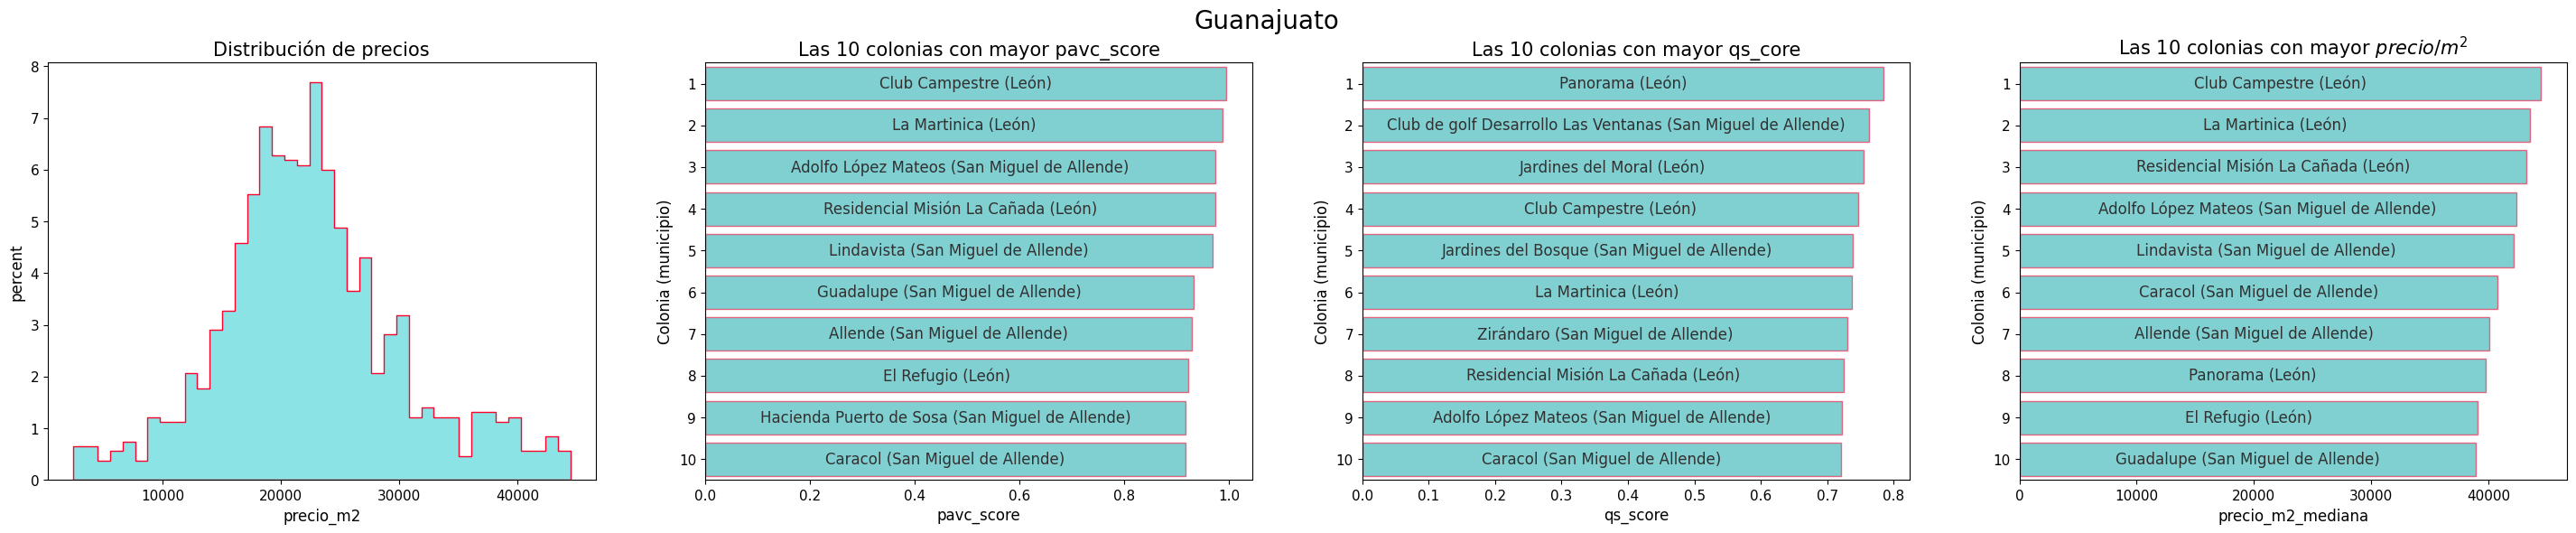

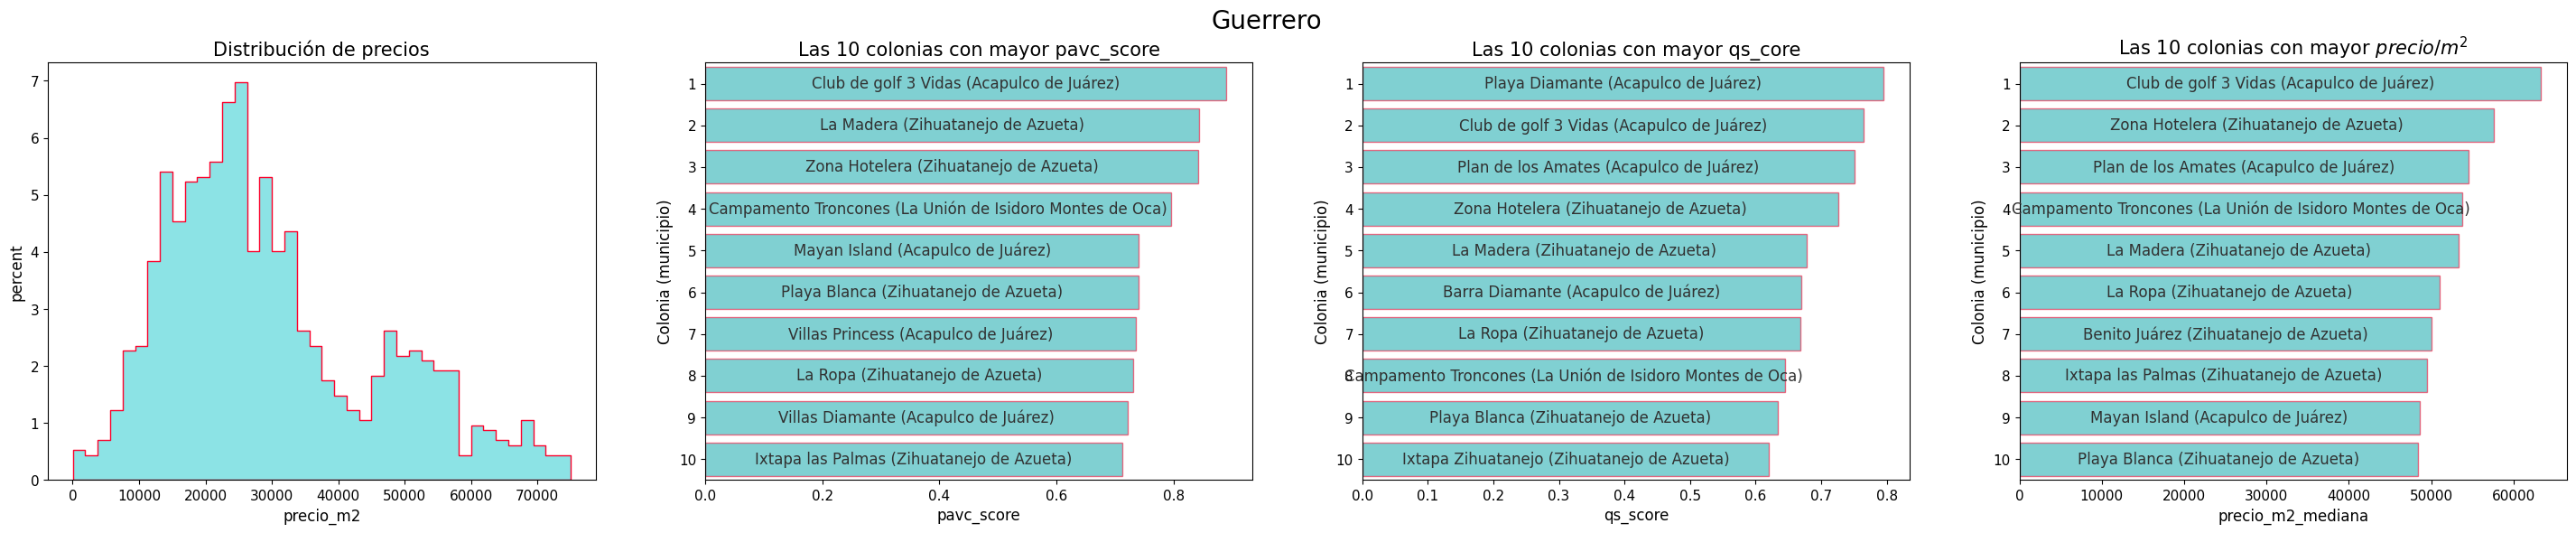

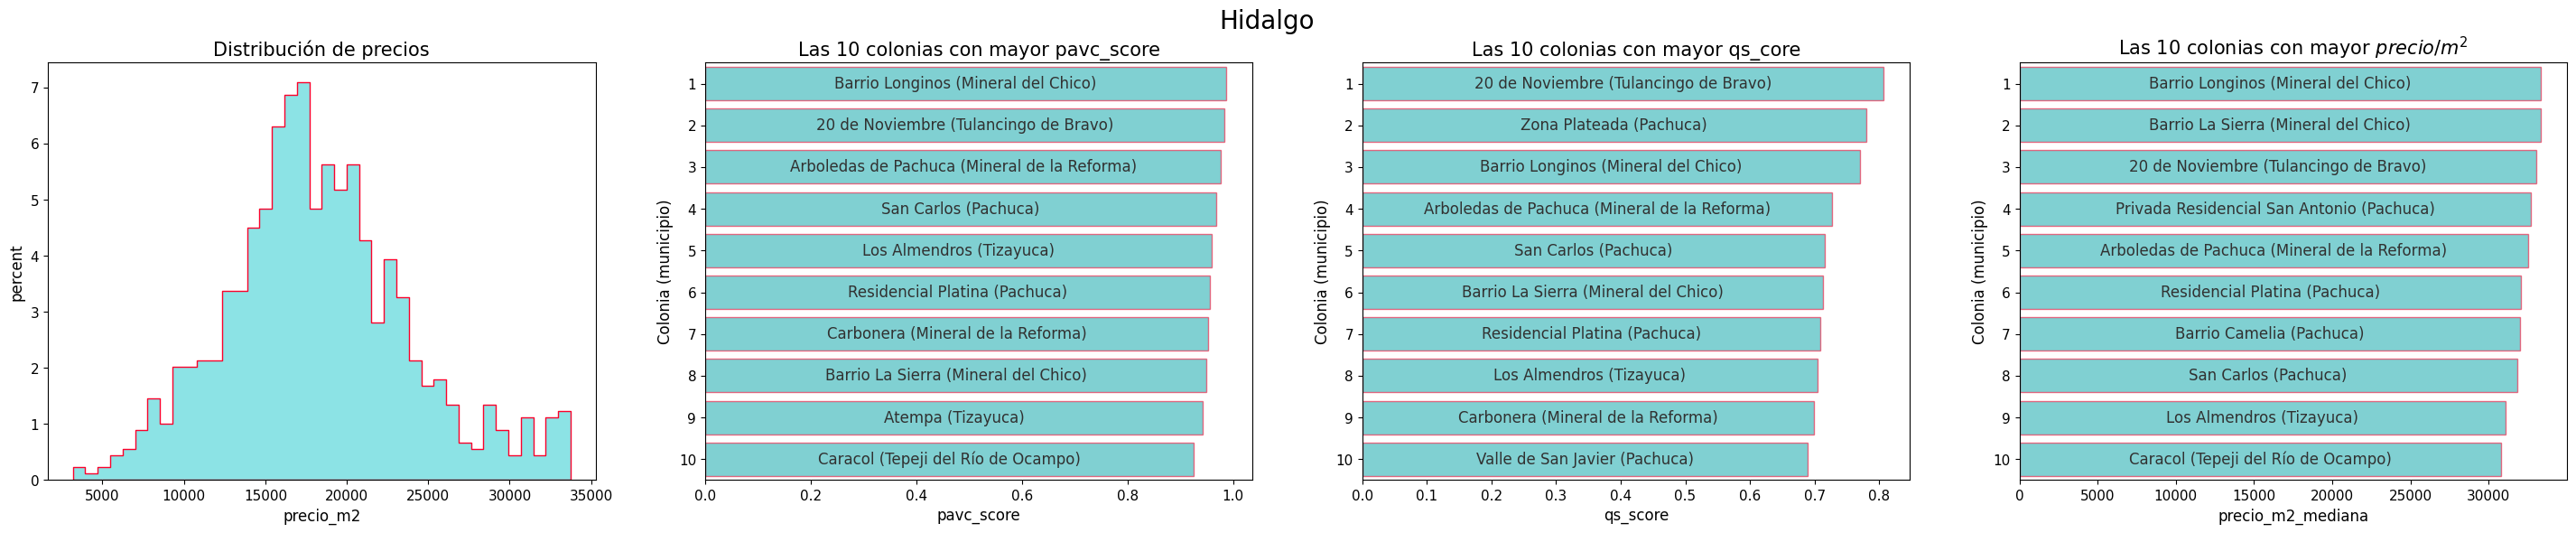

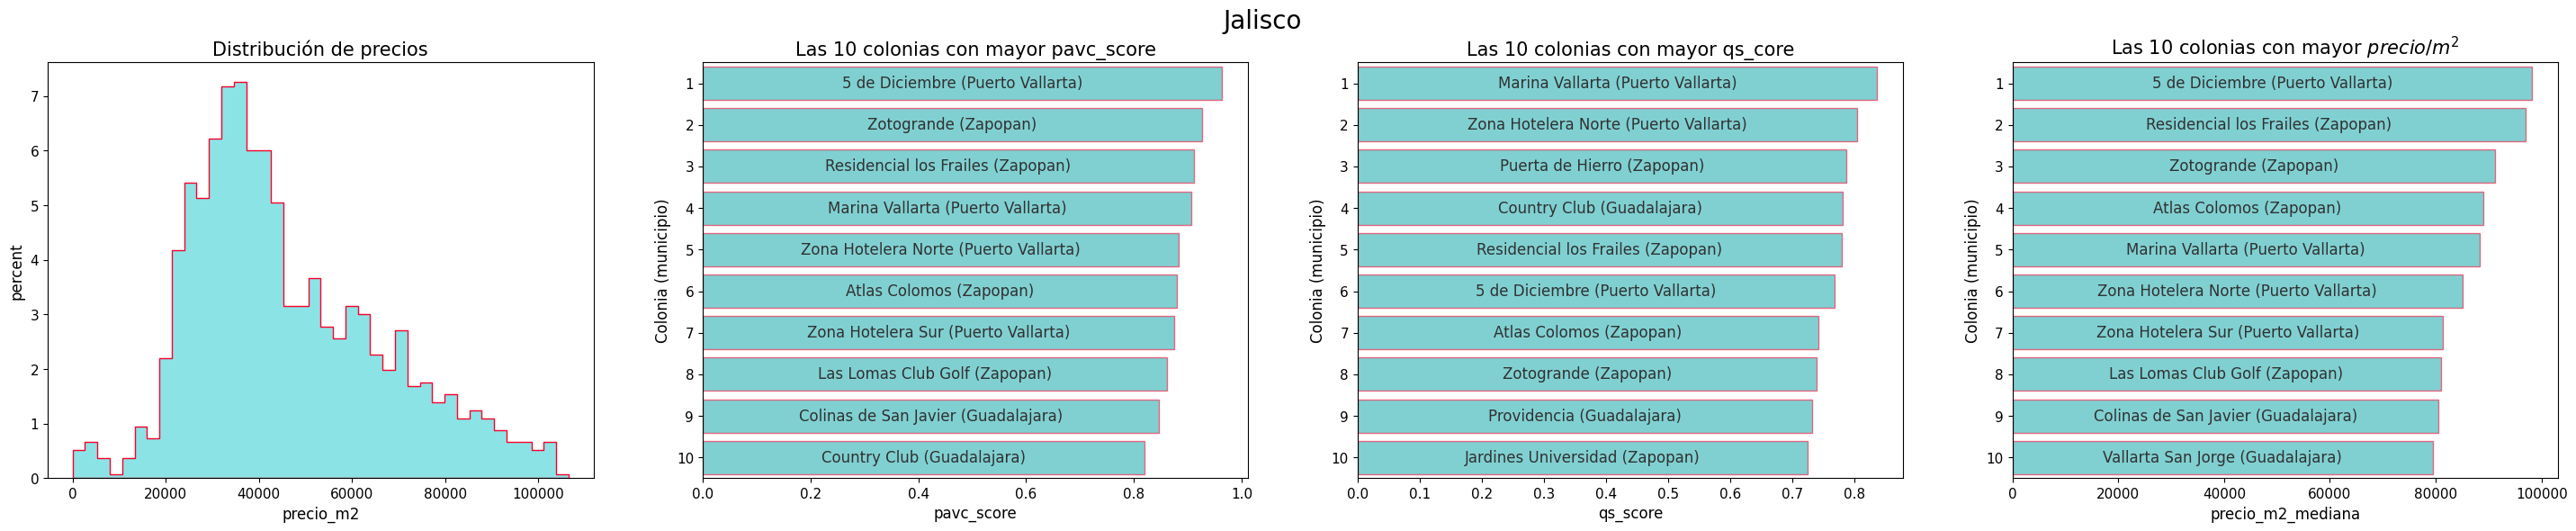

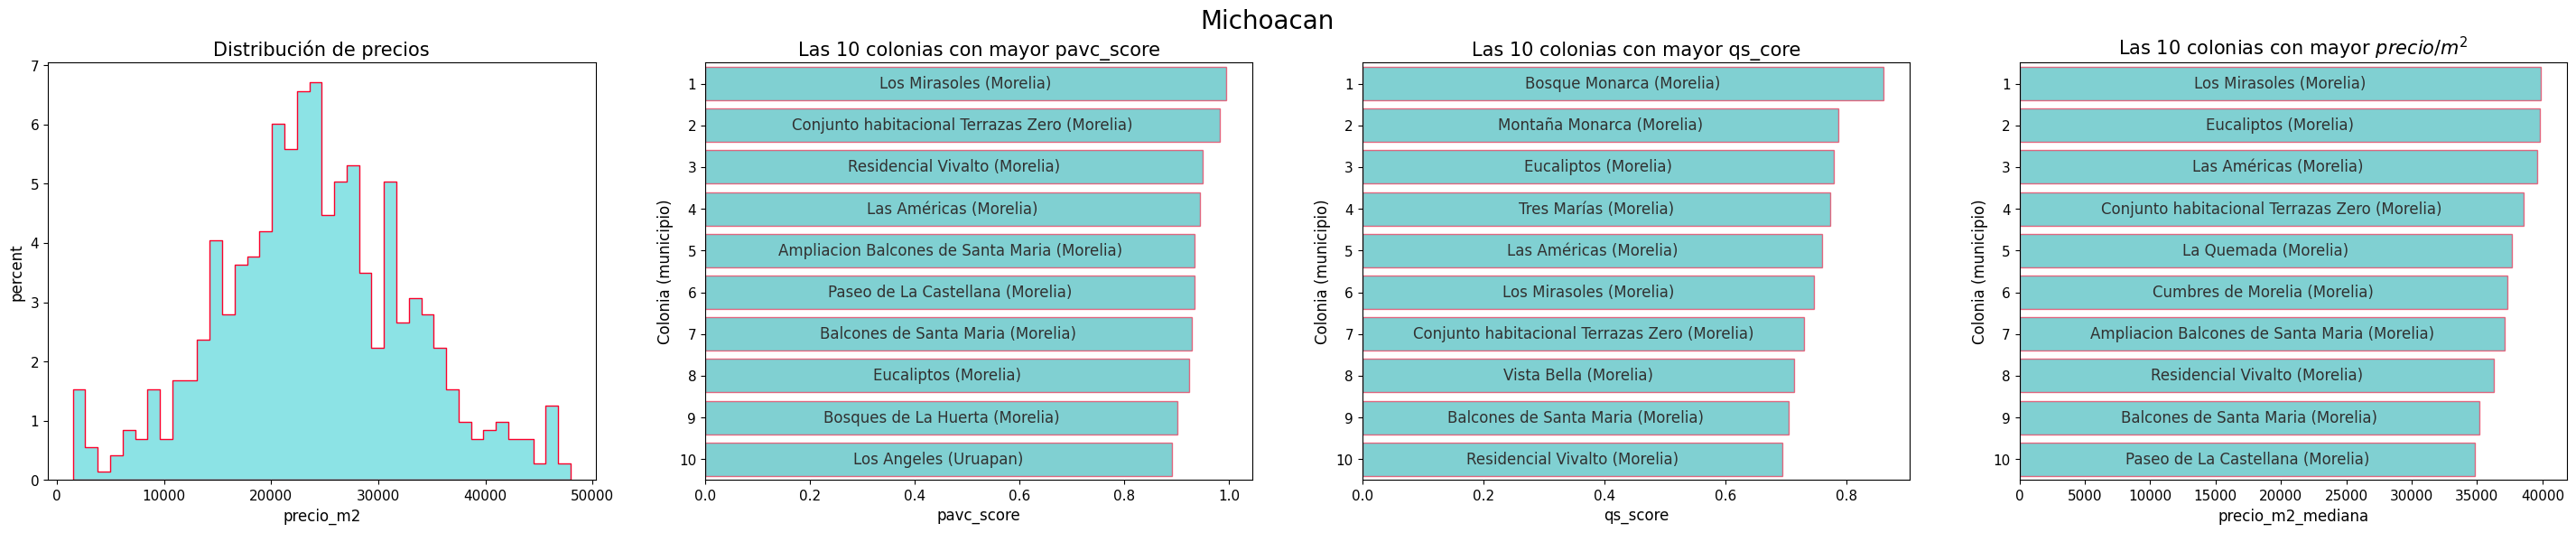

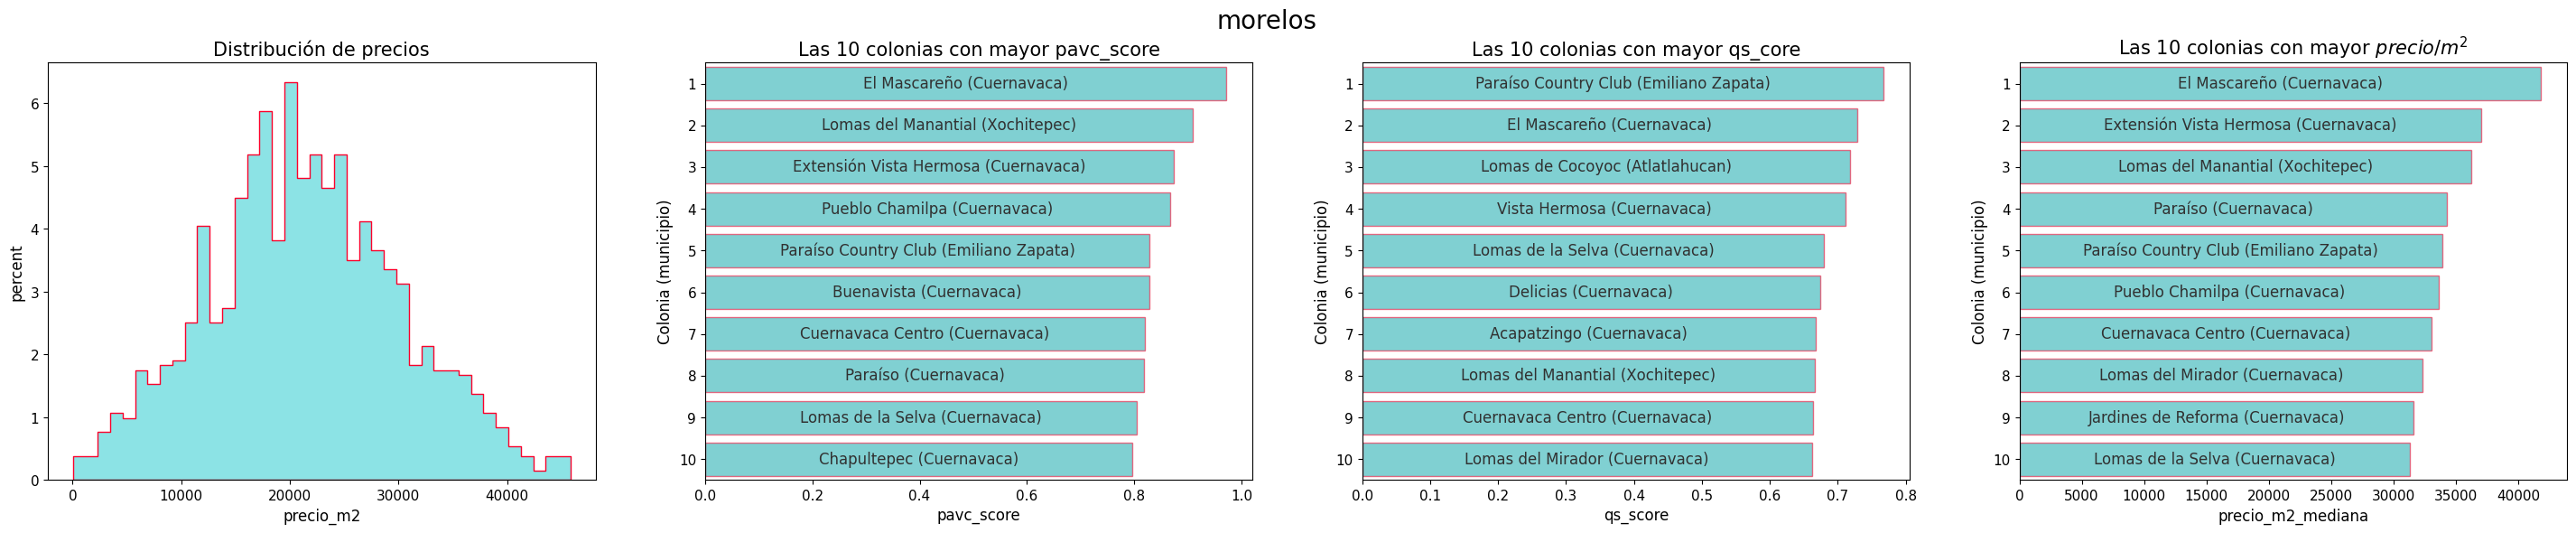

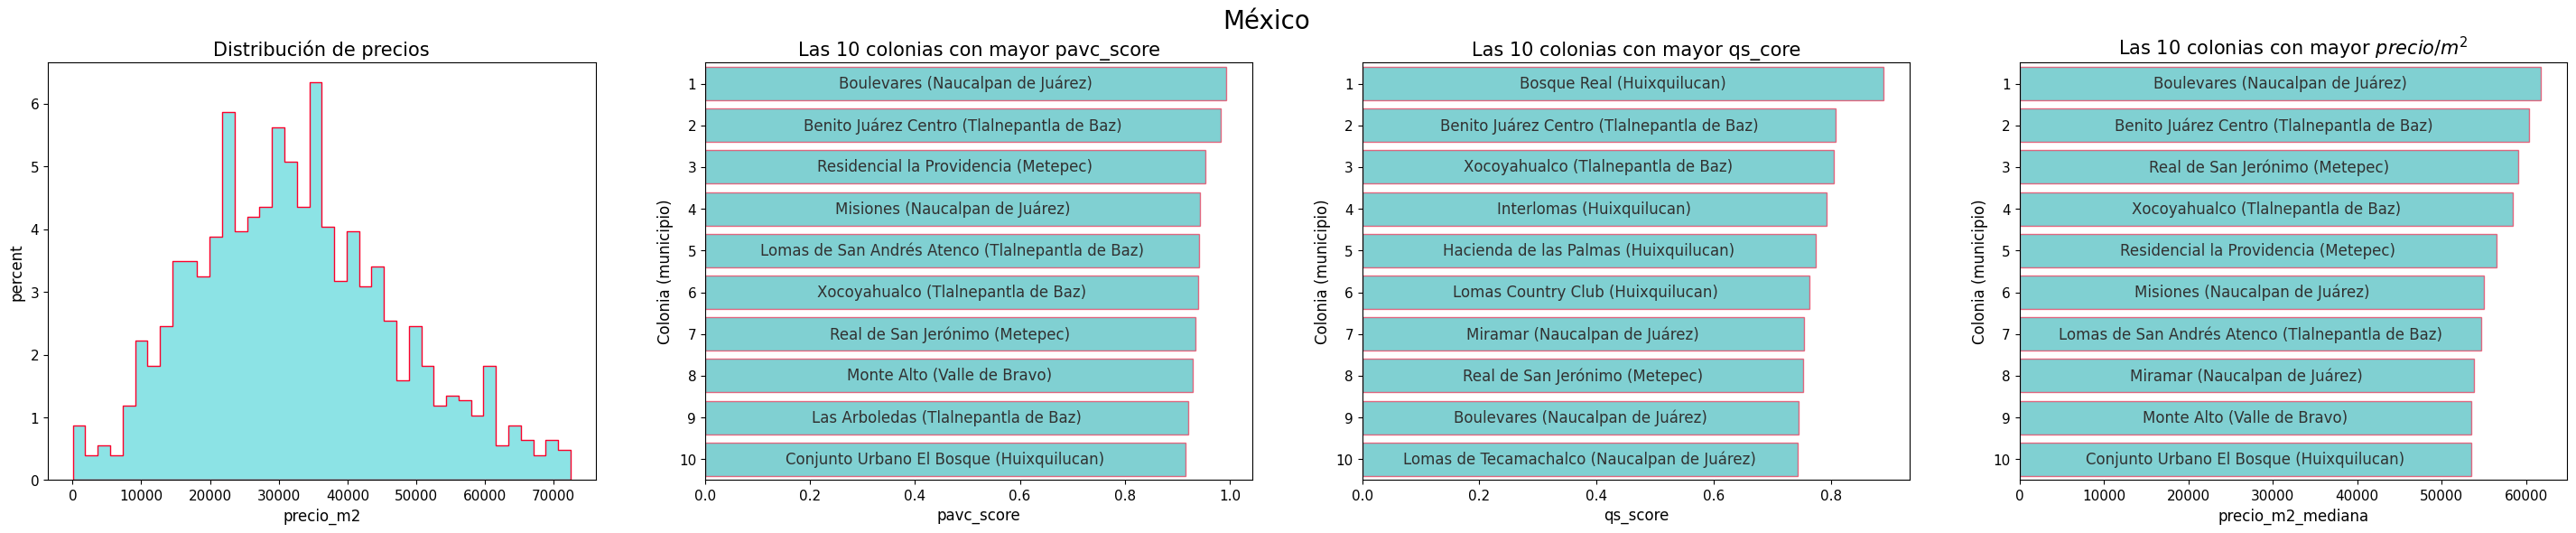

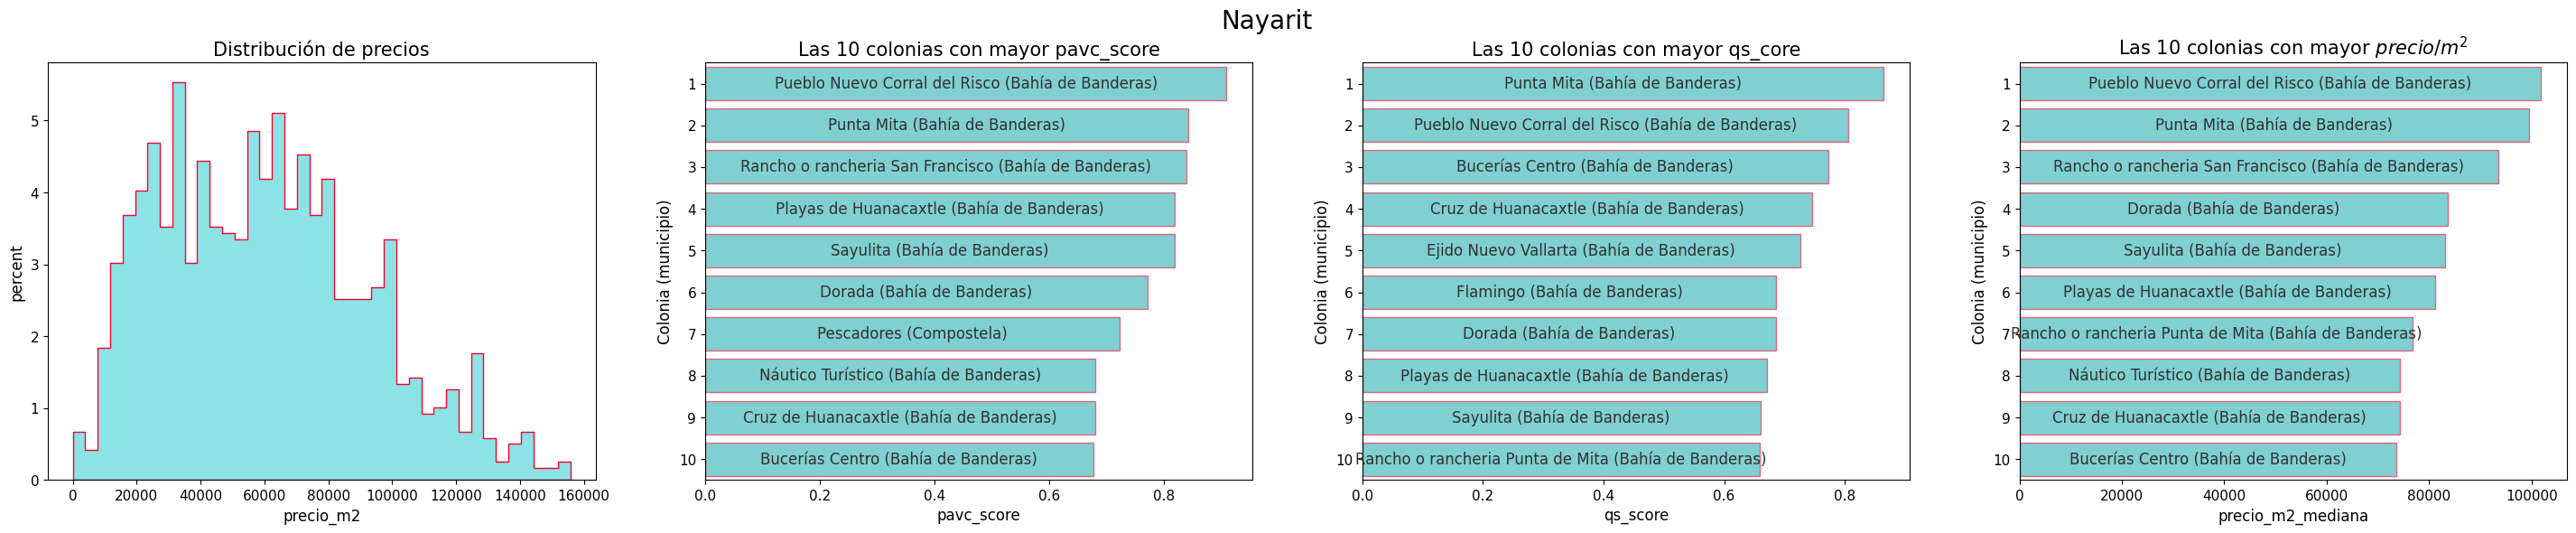

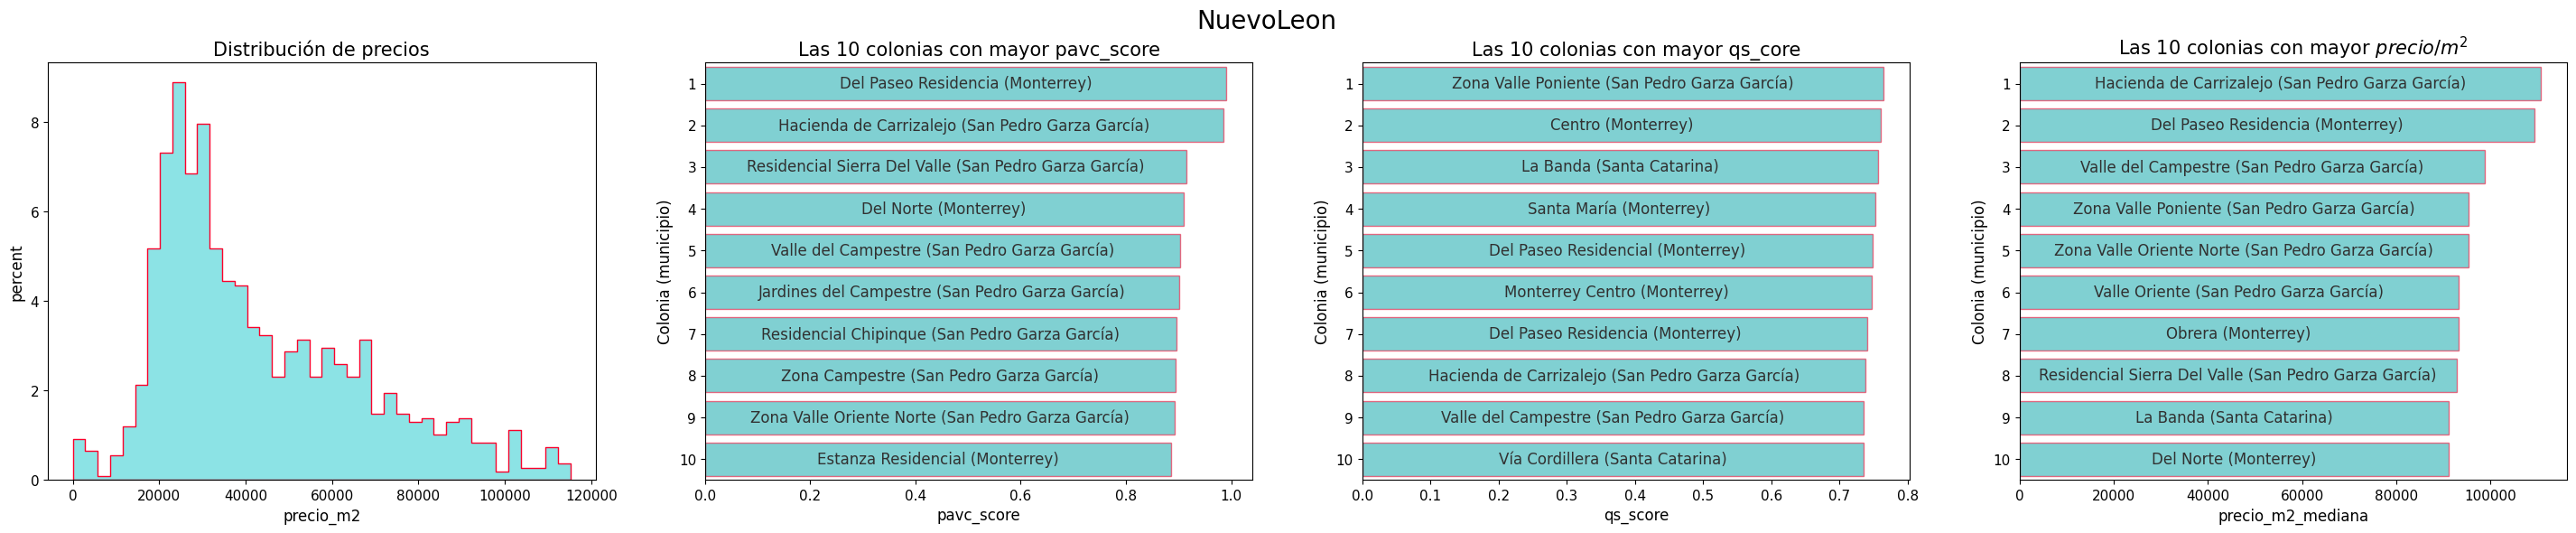

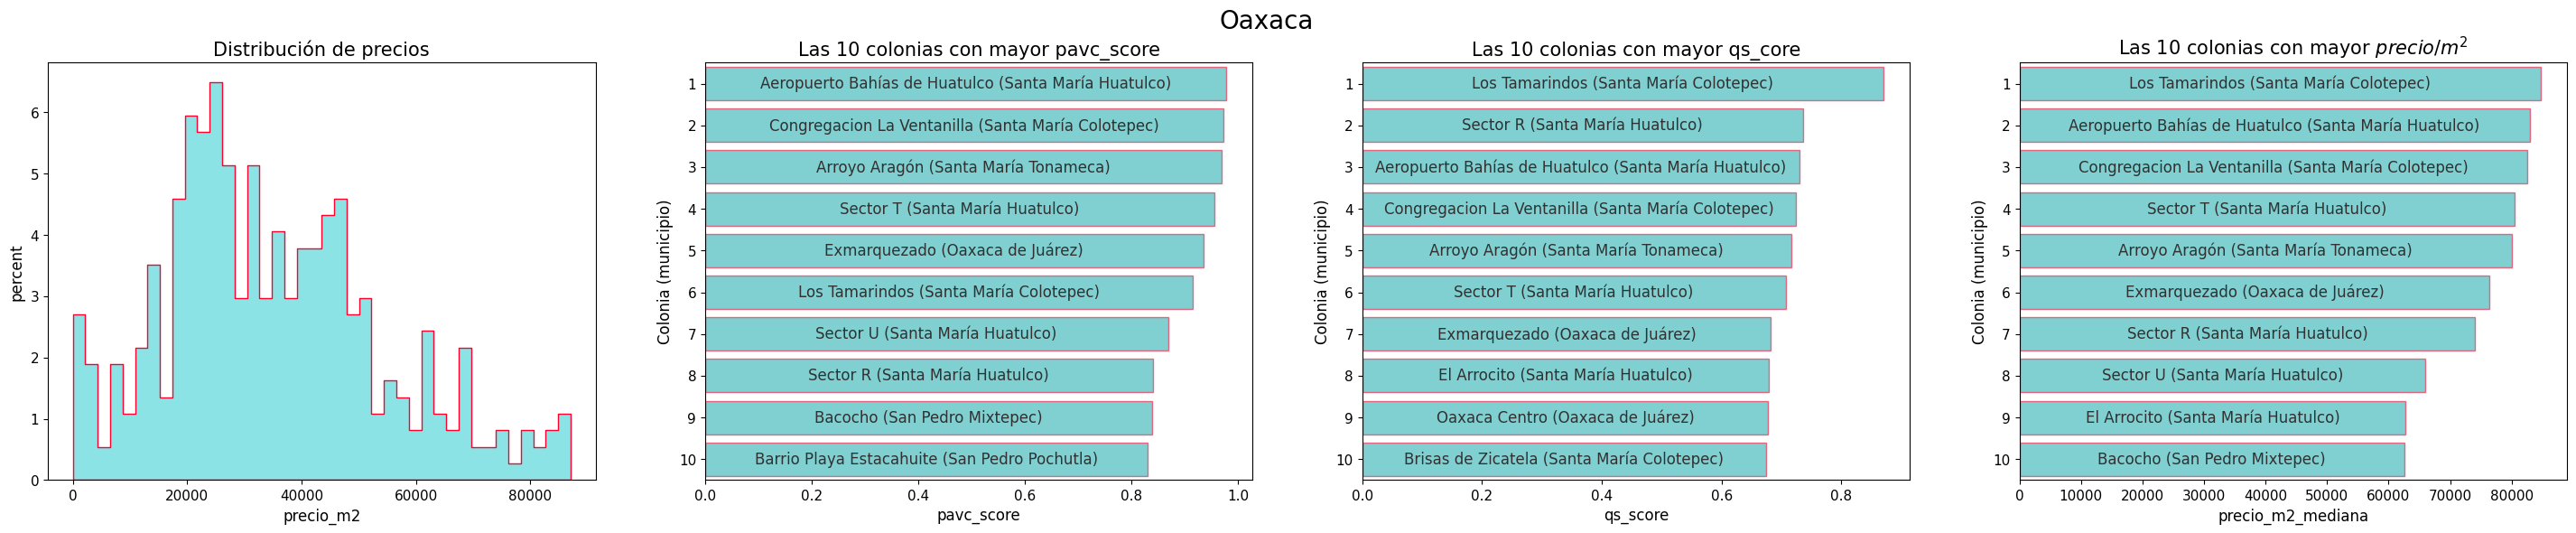

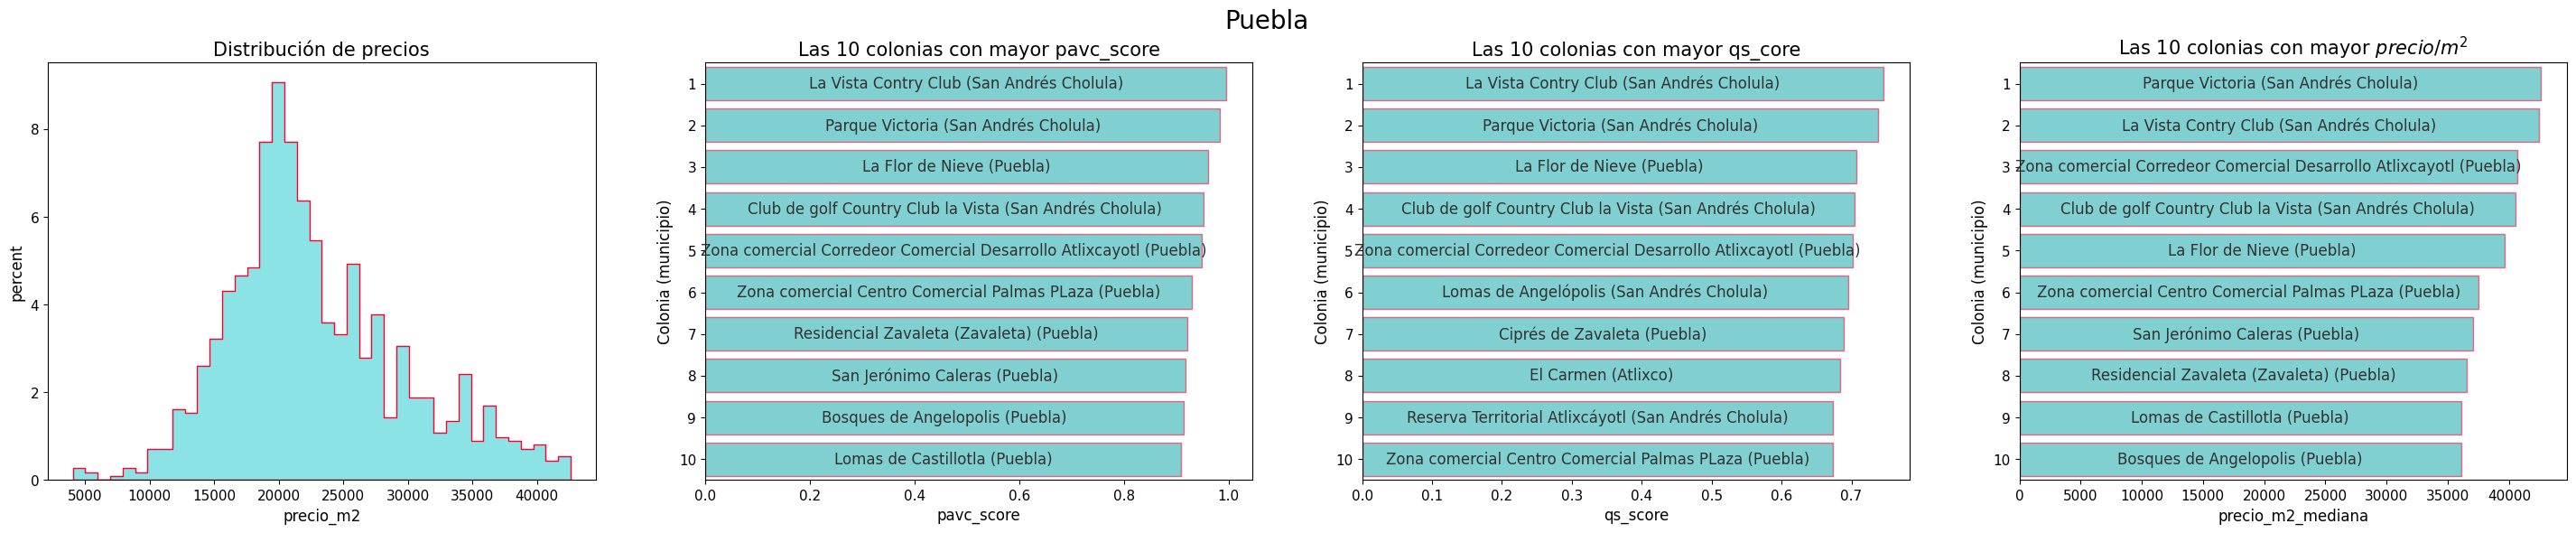

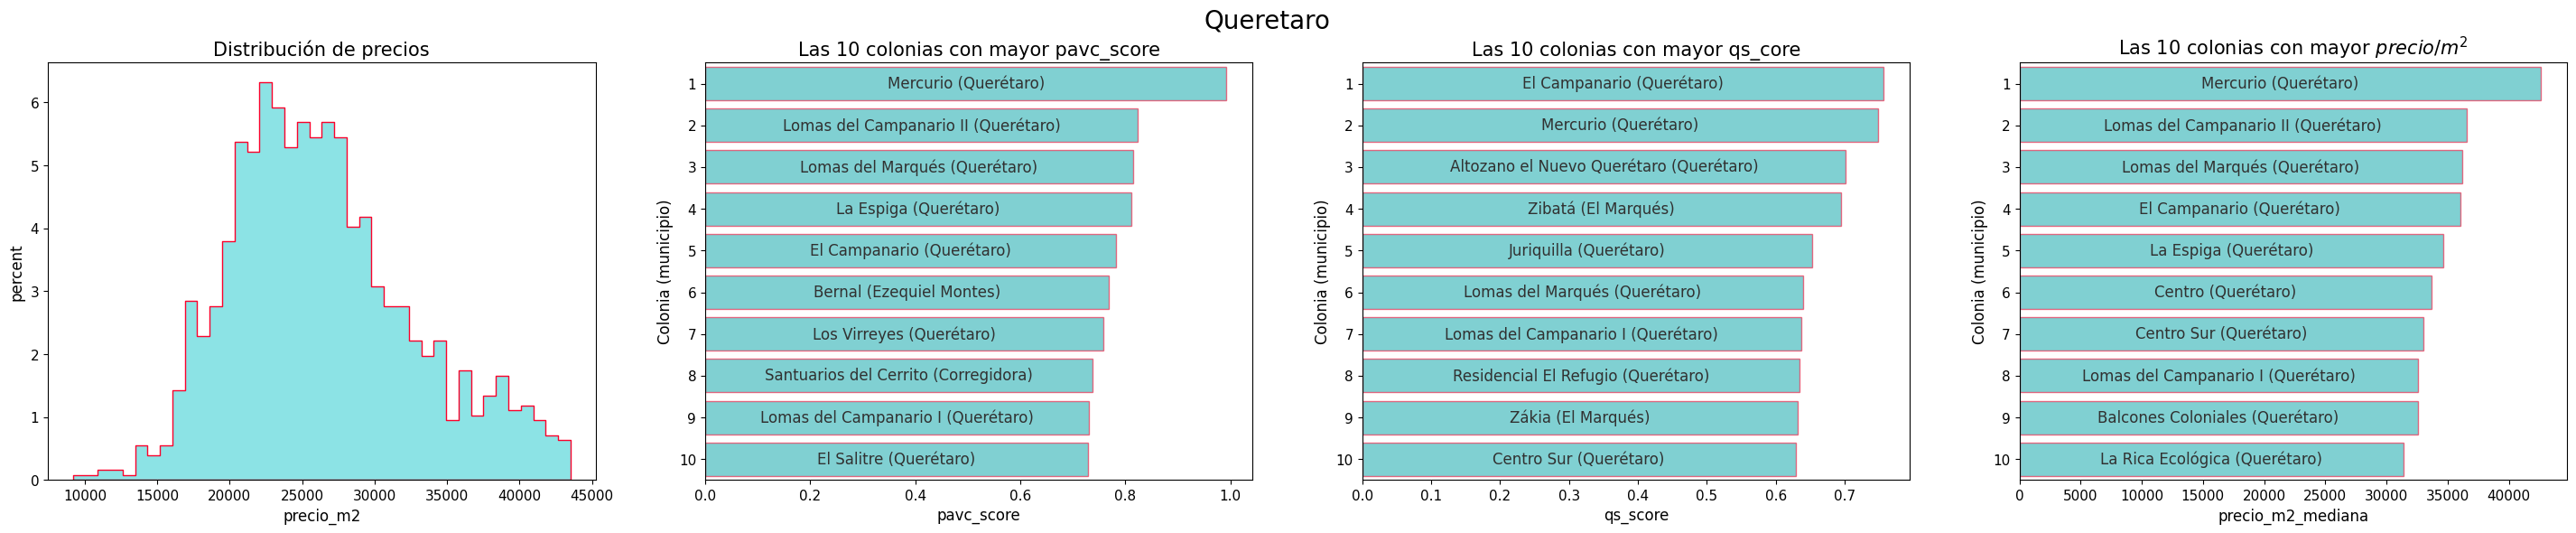

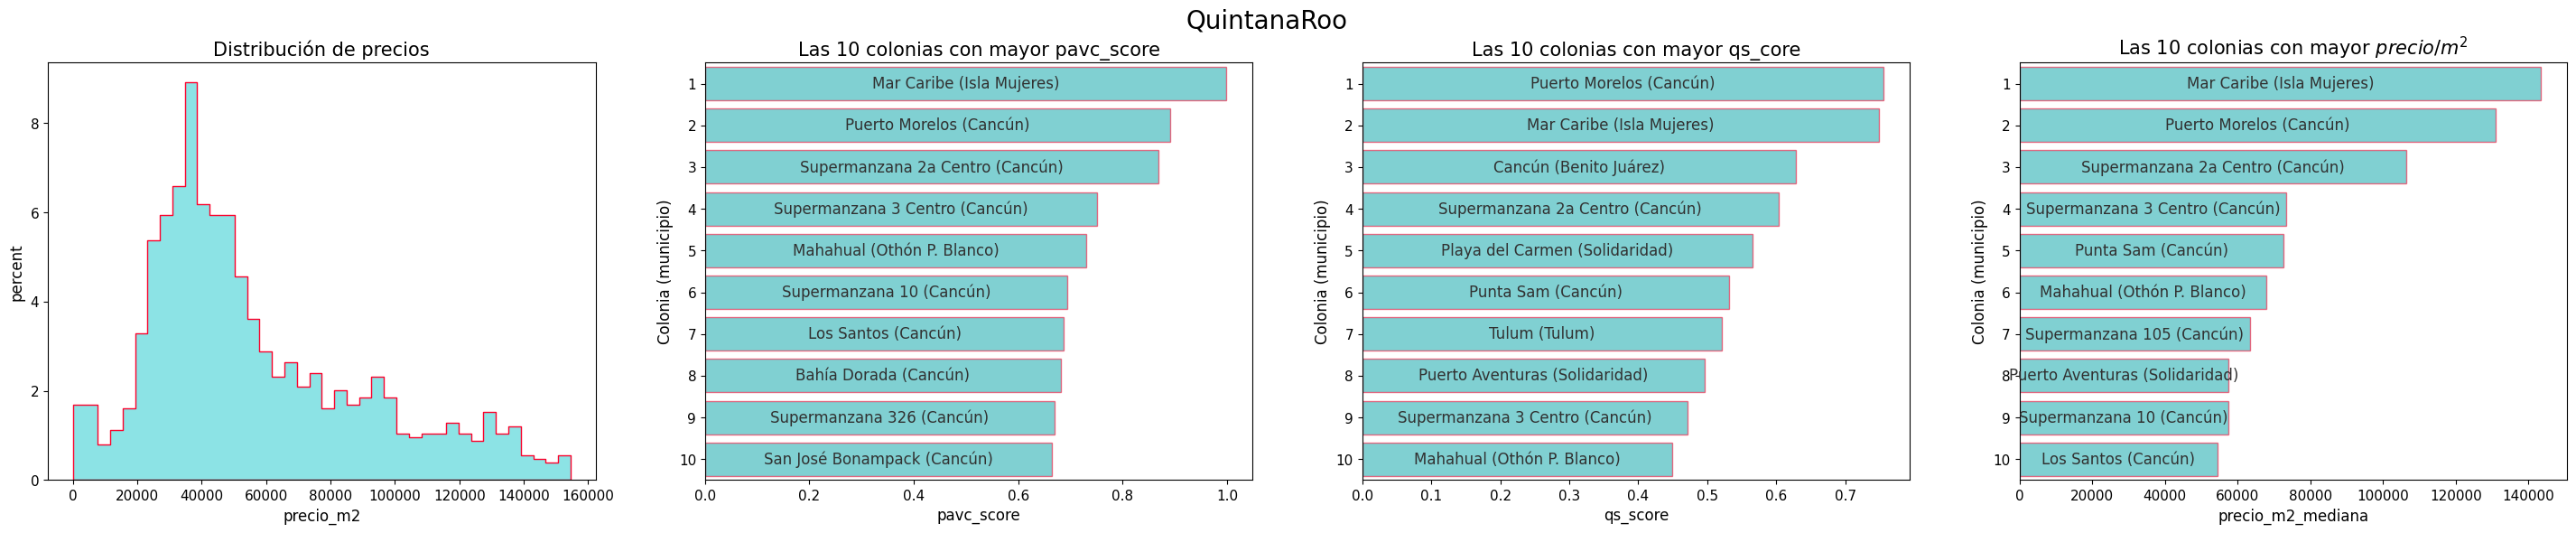

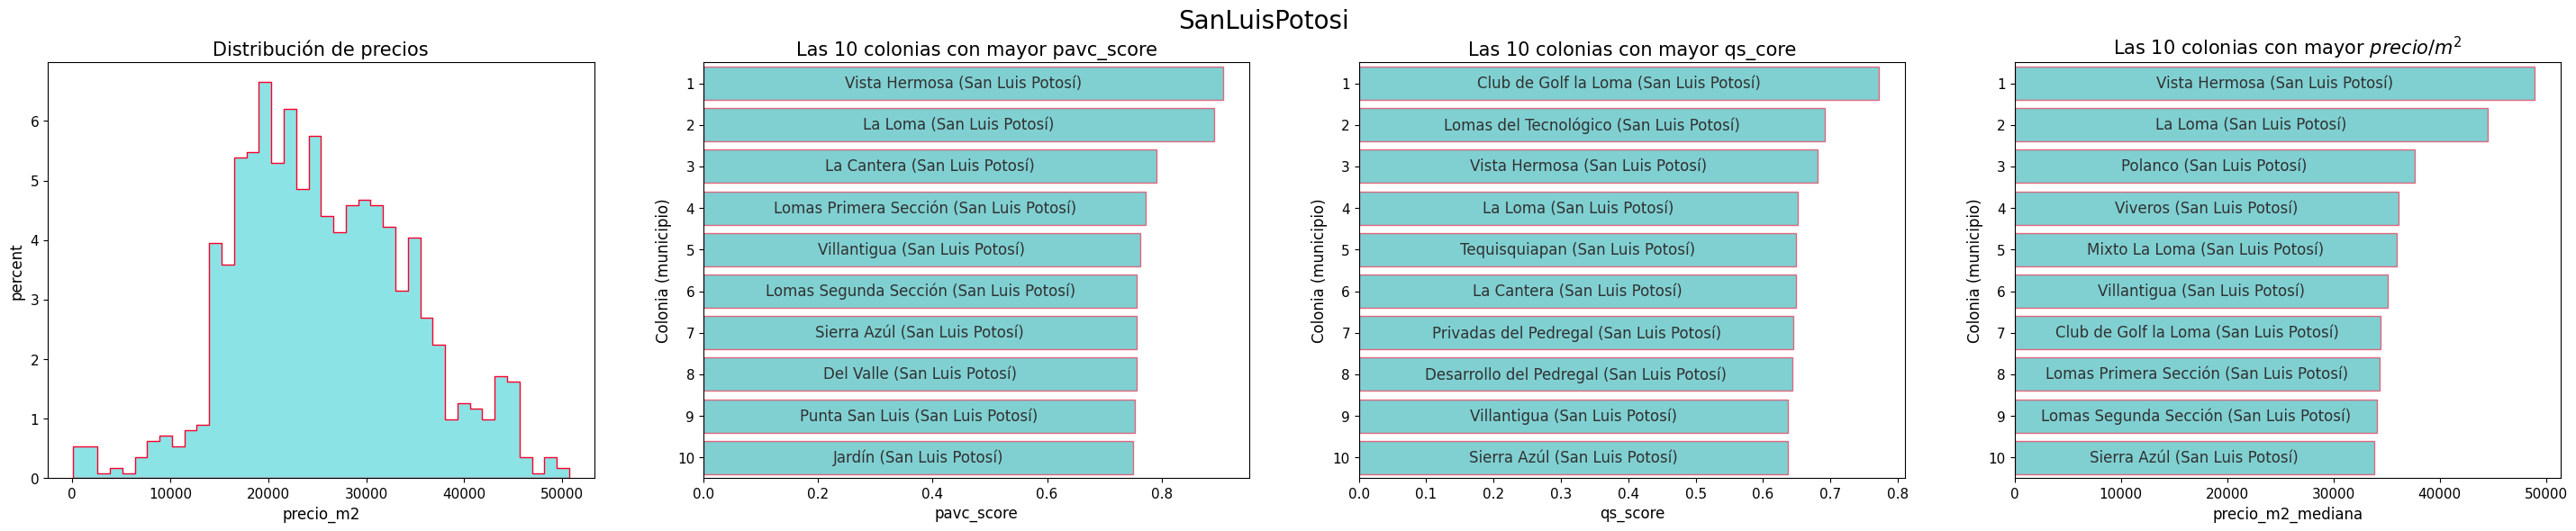

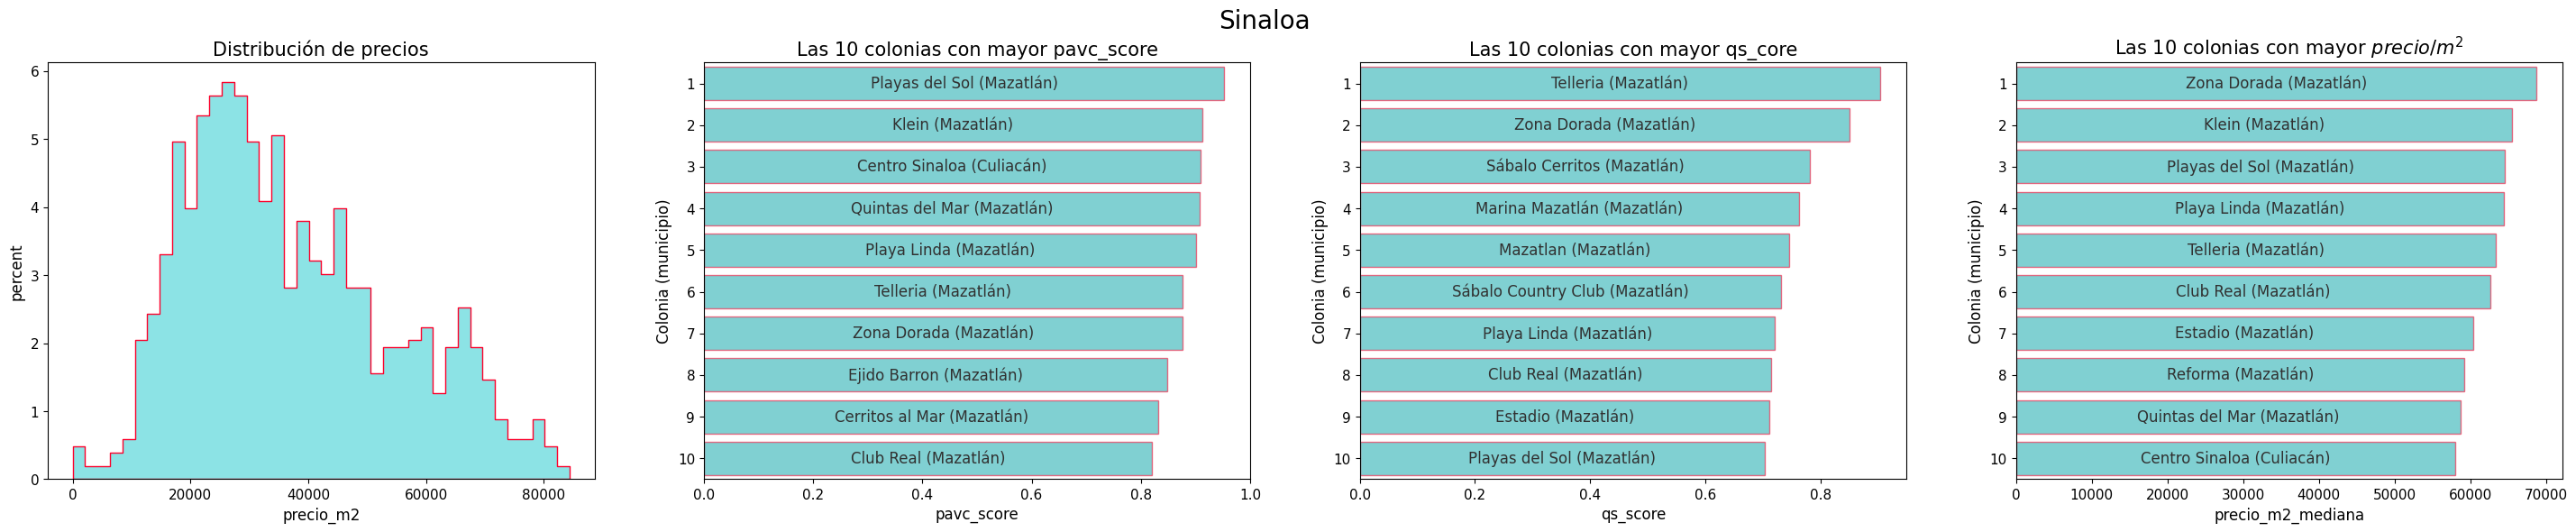

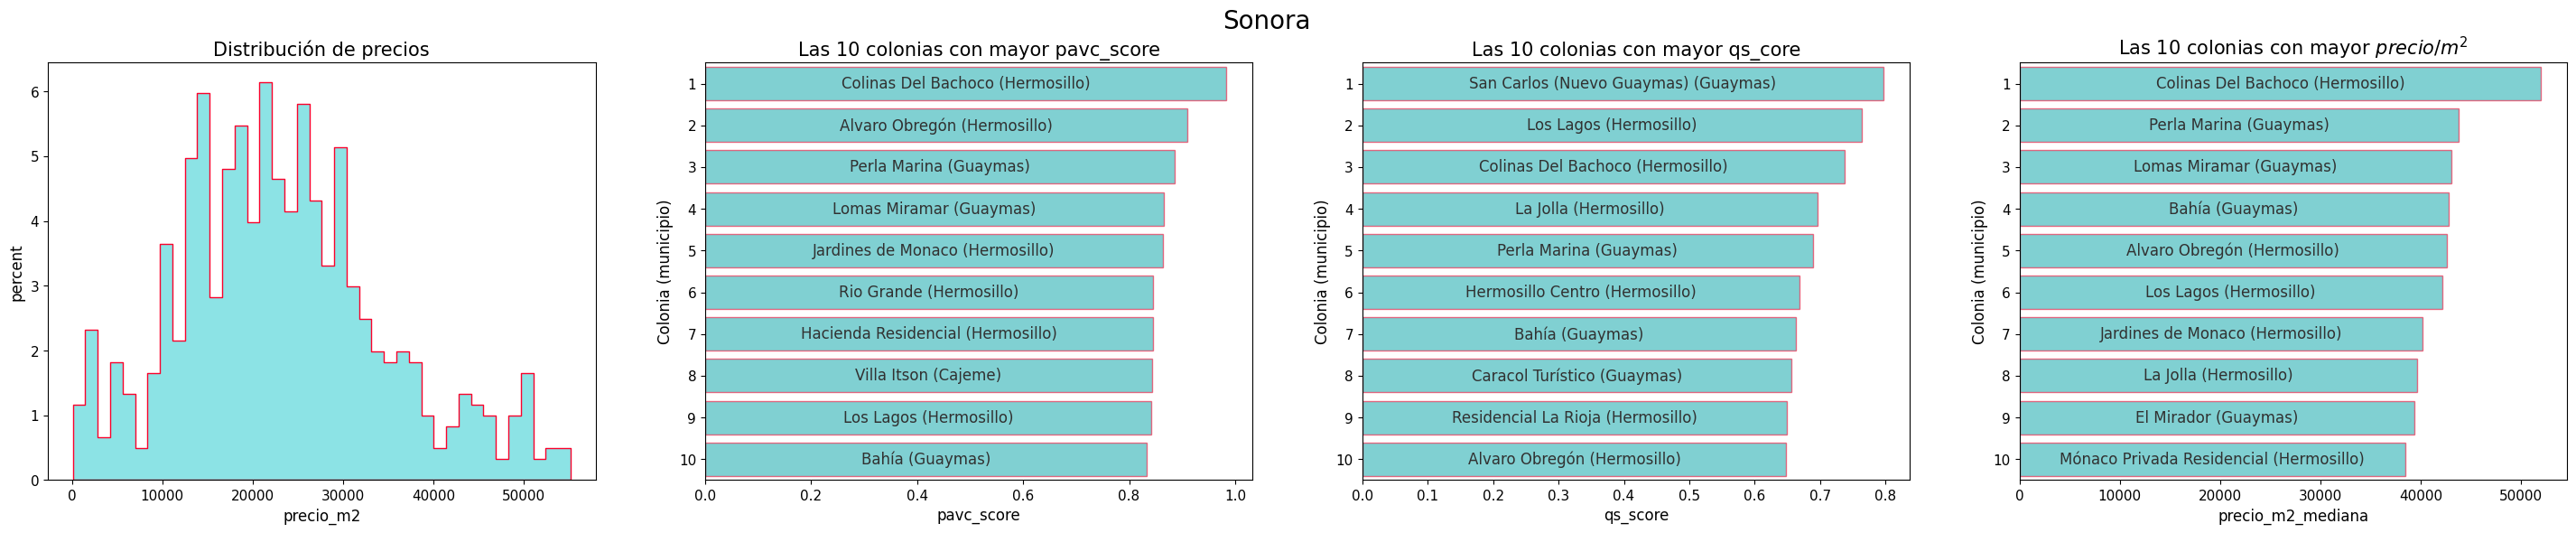

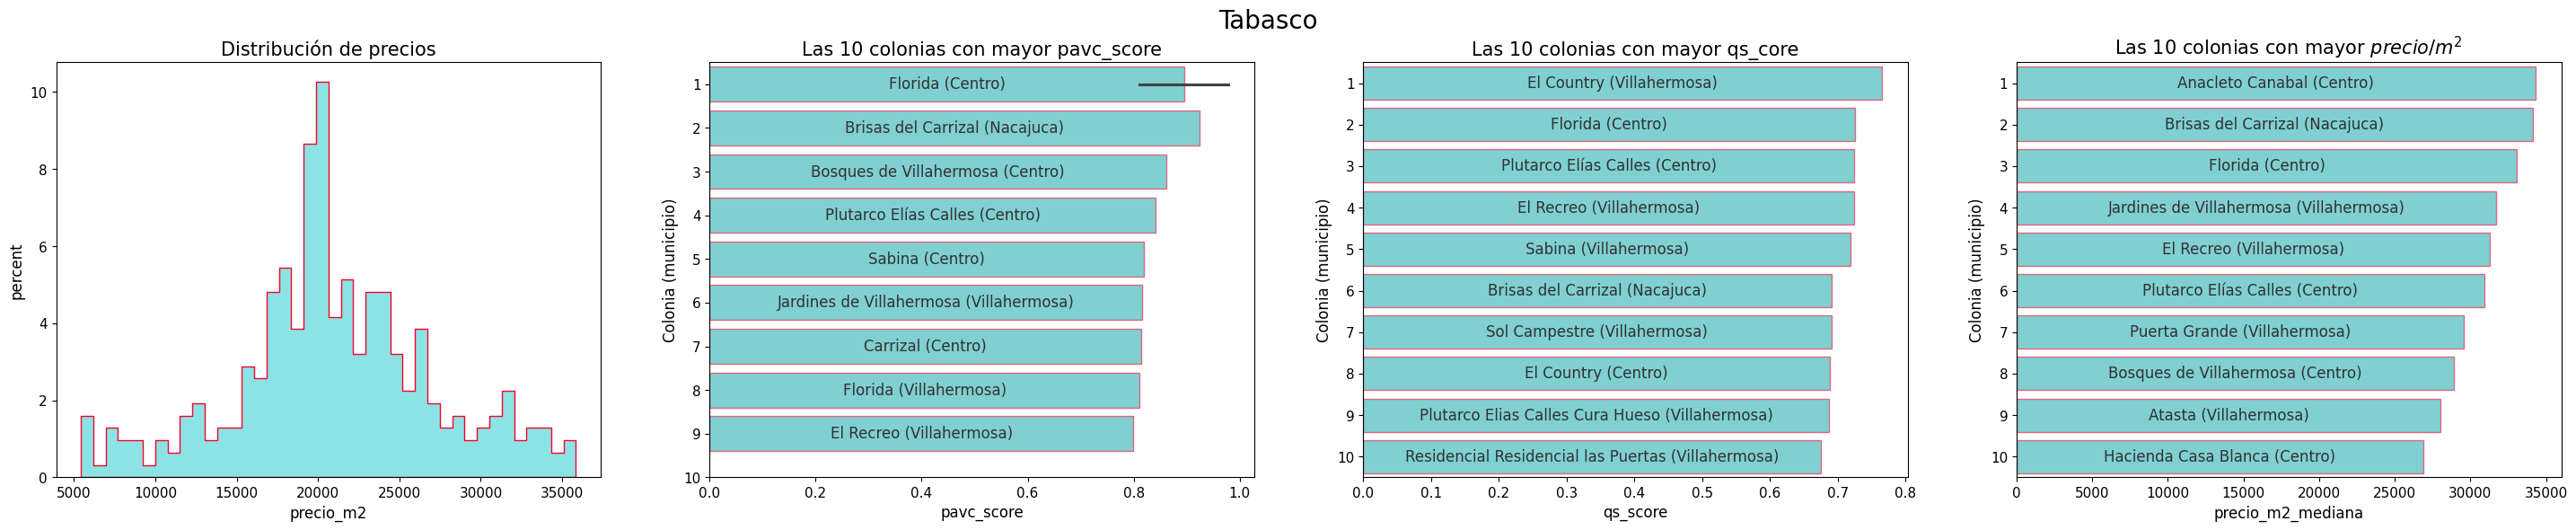

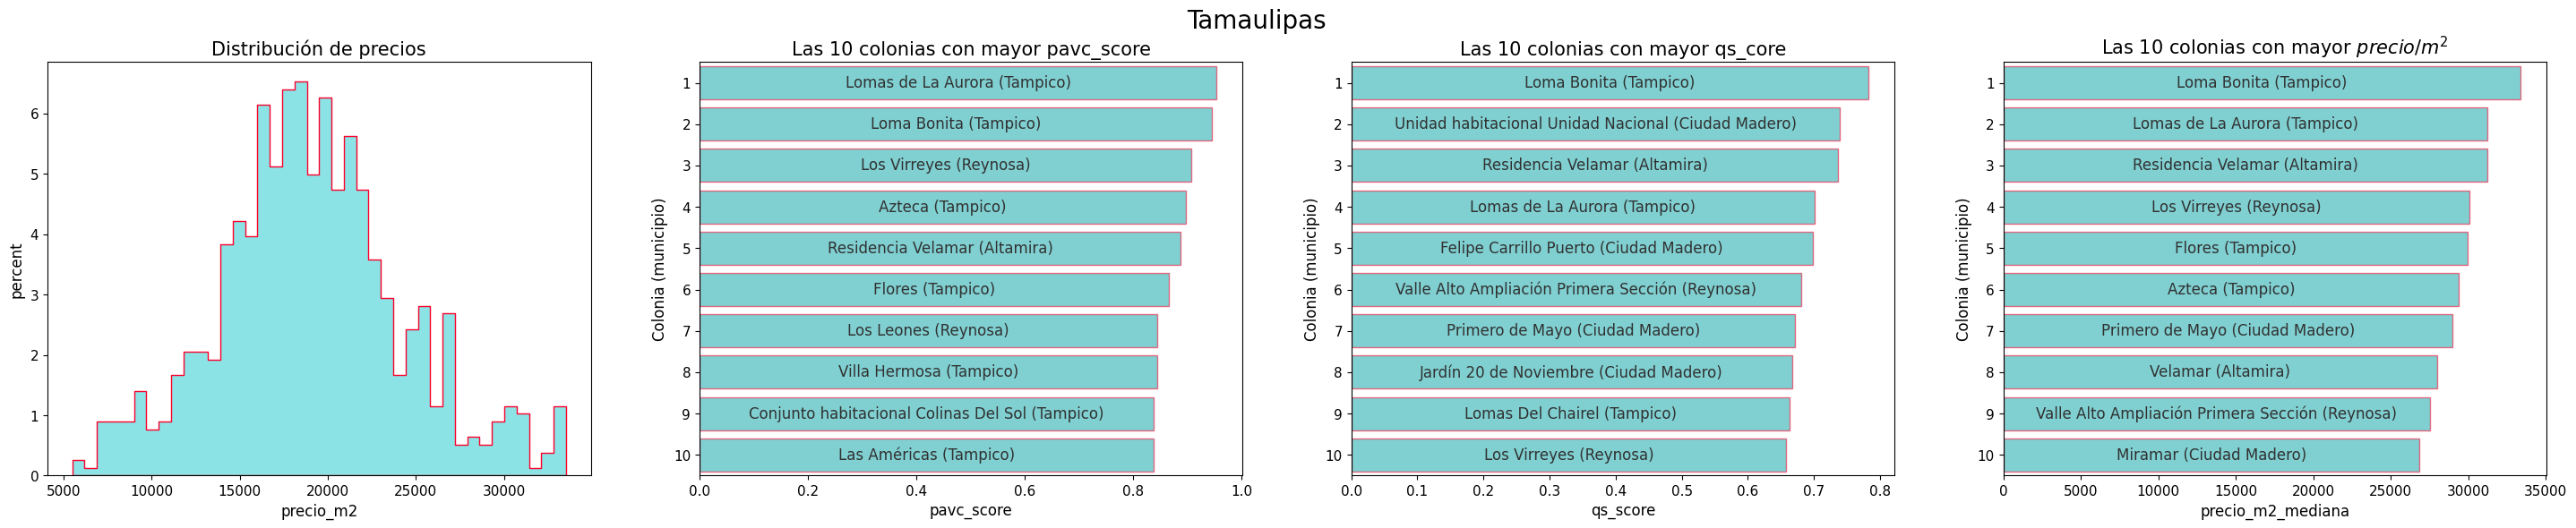

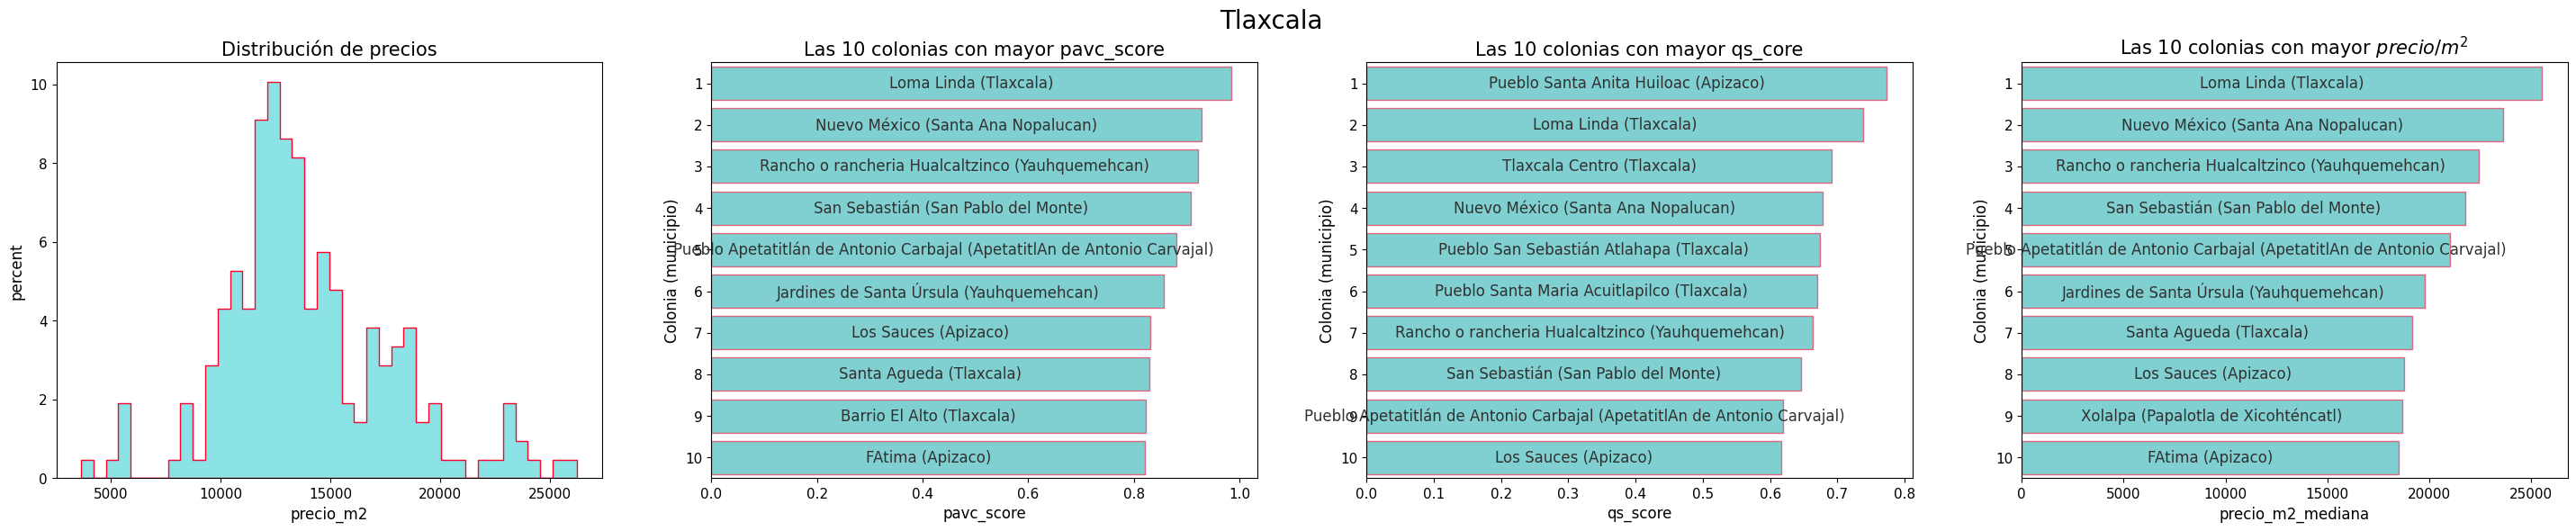

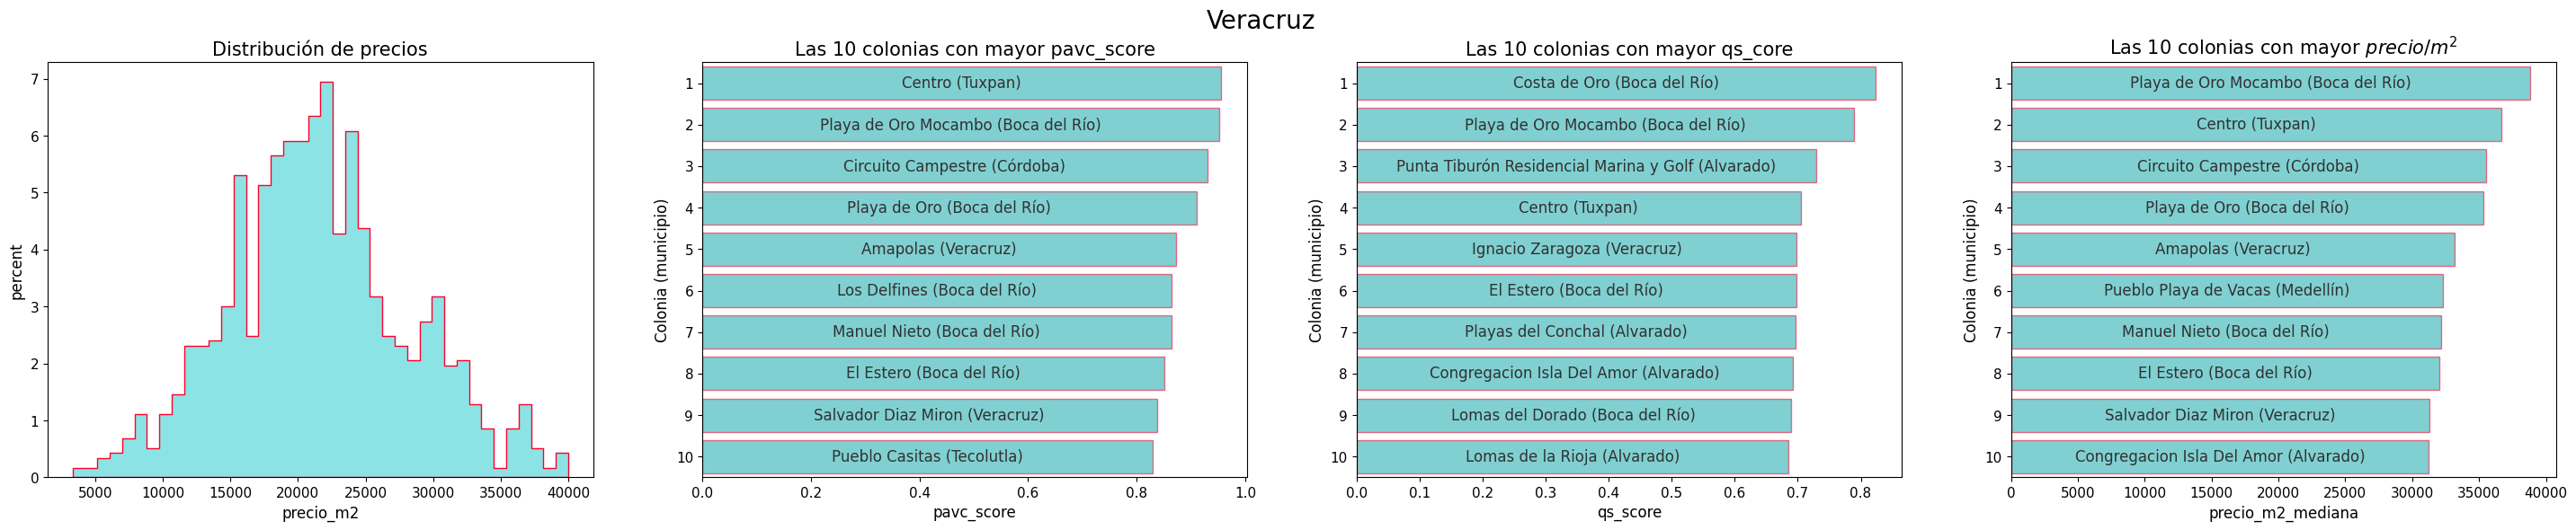

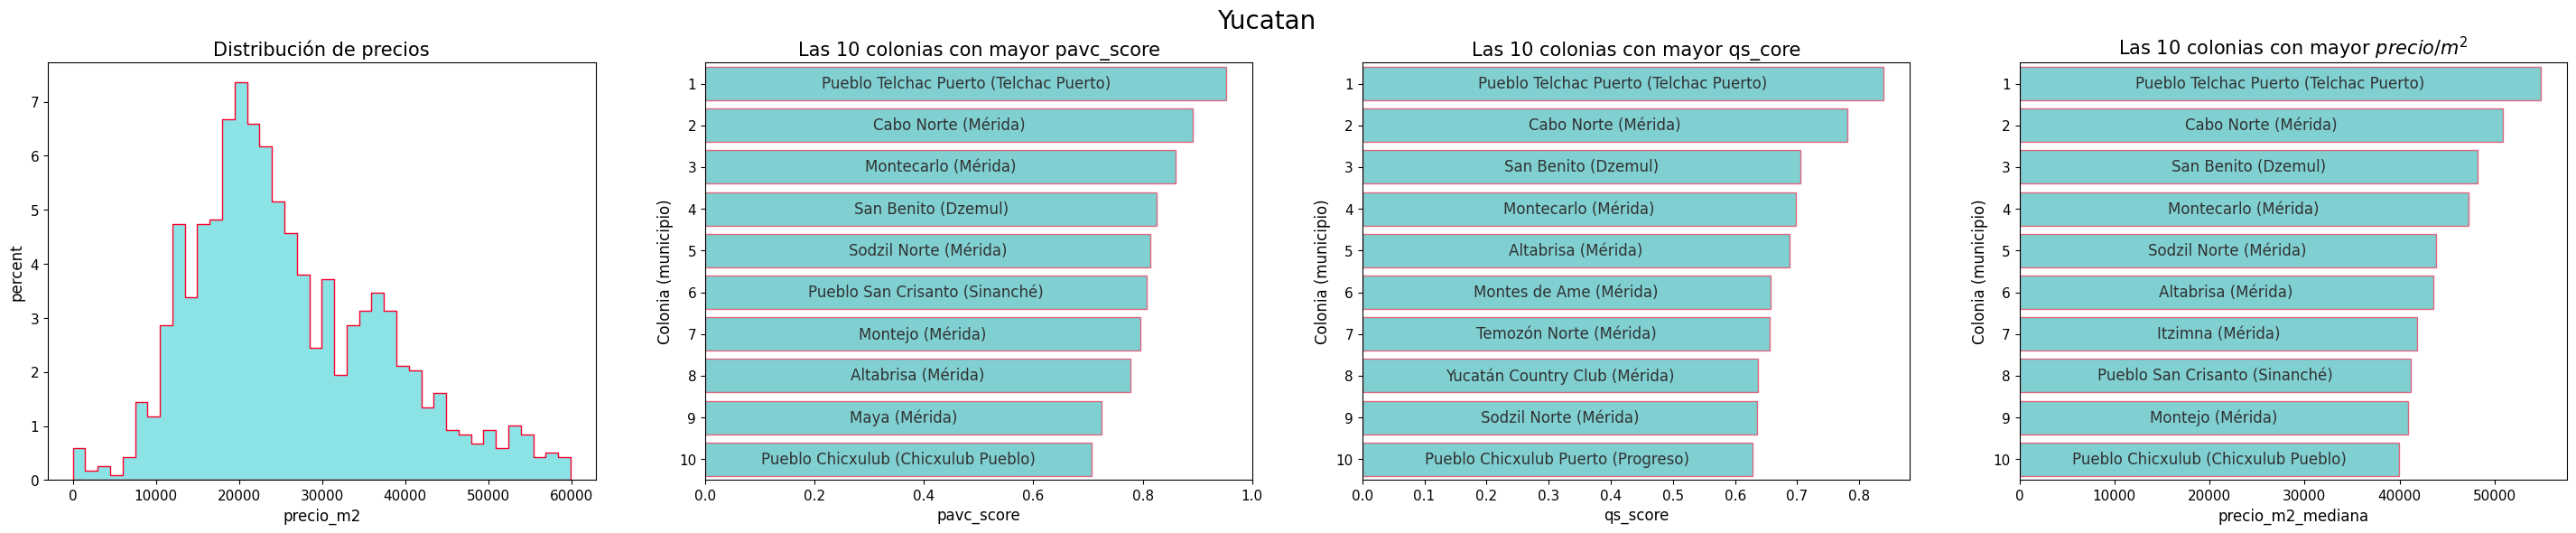

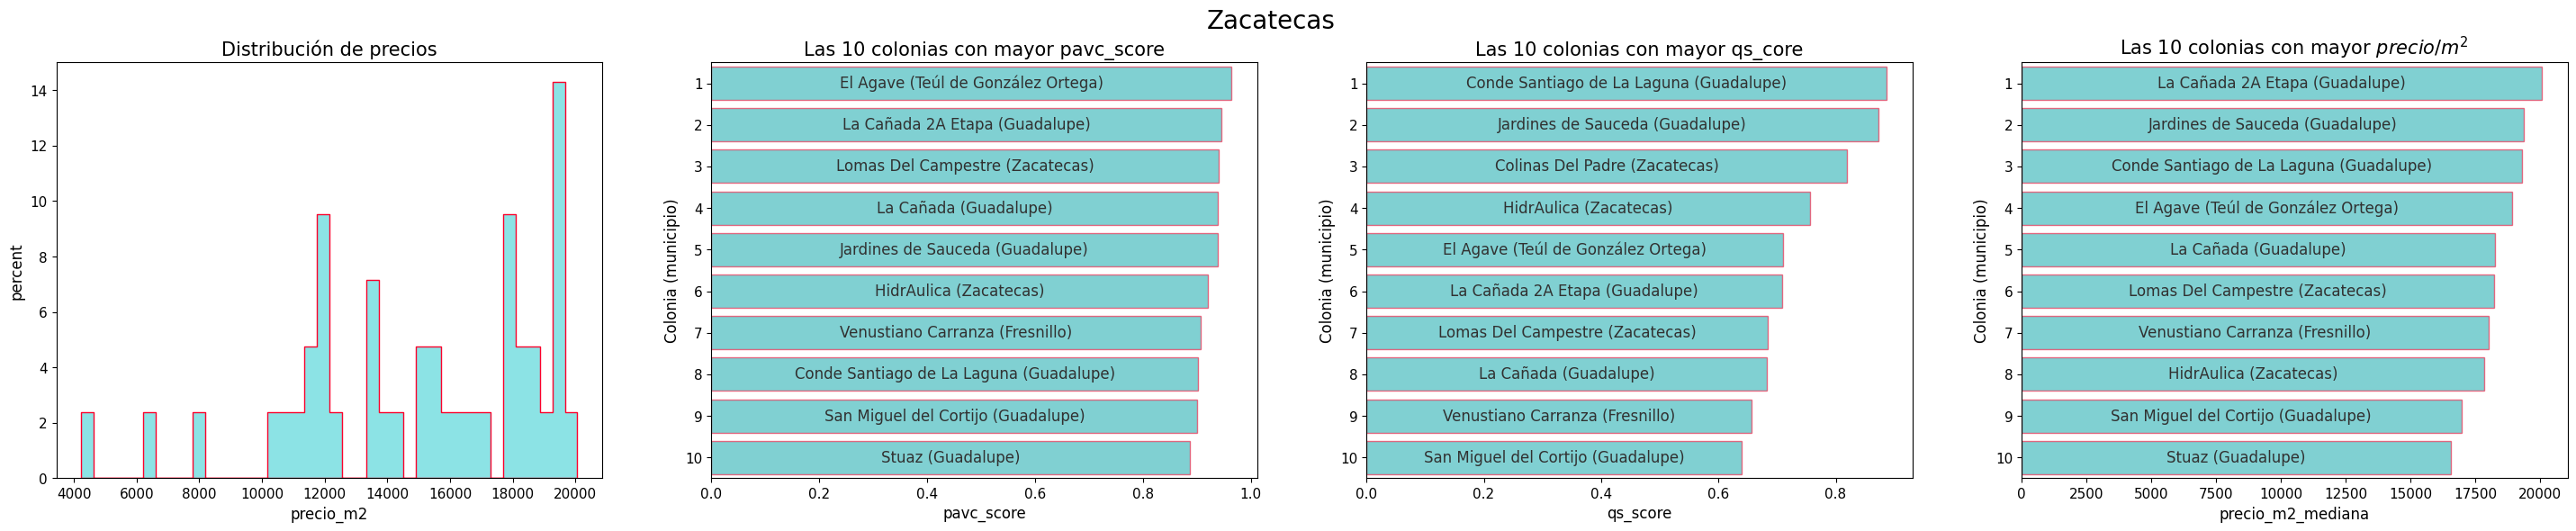

In [ ]:
top = 10
error_states = []
raw_files = [state.name for state in RAW_DATA.iterdir() if state.is_file()]    
for state in raw_files:
    
    #test
    
    state_name = extraer_sufijo_csv(state)#RAW_DATA / "properties_Morelos.csv")
    try:
    #TRATAR Y CARGAR DATOS:
        normalized_mor = full_treatment(RAW_DATA / f"properties_{state_name}.csv")
        full_mor = pd.read_csv(CLEAN_DATA / f"clean_{state_name}.csv") 
        grouped_mor = pd.read_csv(GROUPED_DATA / f"grouped_{state_name}.csv")
        top = min([10, grouped_mor.shape[0]])
        top_score = get_top(normalized_mor, top = top, criterion= "pavc_score")
        top_price = get_top(grouped_mor, top = top, criterion= "precio_m2_mediana")
        top_qs_score = get_top(normalized_mor, top = top, criterion= "qs_score")
    #VISUALIZACIÓN:
        fig, axes = plt.subplots(nrows = 1, ncols = 4, figsize = (36,6))
        plt.suptitle(f"{state_name}", fontsize = 20)

    #TOP MEJOR SCORE
        barplot = bar_plot( data = top_score, 
                        criterion= "pavc_score", 
                        barplot_args= {"color" : paleta["principal"], "edgecolor" : paleta["contraste"], "alpha": 0.55}, 
                        title = f"Las {top} colonias con mayor pavc_score", 
                        ax=axes[1])

        barplot = bar_plot( data = top_qs_score, 
                        criterion= "qs_score", 
                        barplot_args= {"color" : paleta["principal"], "edgecolor" : paleta["contraste"], "alpha": 0.55}, 
                        title = f"Las {top} colonias con mayor qs_core", 
                        ax=axes[2])
    
    #DISTRIBUCIÓN DE PRECIOS POR ESTADO
        histplot = hist_plot(data = full_mor, 
                         column = "precio_m2", 
                         title = f"Distribución de precios",
                         ax = axes[0],
                         histplot_args = {"stat":"percent", 
                                          "color" : paleta["principal"], 
                                          "edgecolor" : paleta["contraste"], 
                                          "alpha": 0.45, 
                                          "element": "step", 
                                          "bins": 40})
    
    #TOP PRECIO/M2 MÁS ALTO
        barplot = bar_plot( data = top_price, 
                        criterion= "precio_m2_mediana", 
                        barplot_args= {"color" : paleta["principal"], "edgecolor" : paleta["contraste"], "alpha": 0.55}, 
                        title = fr"Las {top} colonias con mayor $precio/m^2$", 
                        ax=axes[3])
        plt.show()
    except:
        print(f"{state_name} dió algún error")
        error_states.append(state)
    #plt.tight_layout()